# Figure 5c-d — headless vs intact walking, matched step cycles

Execution order is load-bearing: the PCA is fitted on all intact frames and never refitted;
`CYC_H`/`CYC_HL` and `PAIRS` come from the cycle table; `_LOOPS` and the `PDF_*` grids feed
the panel. Run top to bottom.
Fit a StandardScaler + PCA on **healthy free-walking** leg kinematics, then `.transform()`
**headless BDN2** flies into that fixed space. 

**The intact set is speed-matched to the headless one.** Headless
flies walk at a median of about 3 mm/s while healthy flies walk at about 16 mm/s, and the two
speed distributions share only ~26 % of their mass. Fitting the PCA on all healthy speeds
builds a space dominated by fast walking that headless flies never produce, so any
"headless is different" result partly just restates "headless is slow".

Healthy data is the ** running h5** 

In [1]:
import sys
import numpy as np
import pandas as pd
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from scipy import signal
from scipy.signal import hilbert, find_peaks
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
from scipy.stats import circmean, circstd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add repo root to path for utils.io_dict_to_hdf5
_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10


In [2]:
# Configuration
FPS = 800                 # Hz (all three datasets: source_hz=800, dt=0.00125)
SMOOTH_SIGMA = 6          # Gaussian sigma (frames) for Hilbert phase
REFERENCE_LEG = 'T1_left'
HEADING_BODIES = ['thorax']
N_PCA_COMPONENTS = 10
INCLUDE_DERIVATIVES = True   # True -> angles + velocities (mirrors Cell 36); False -> angles only

JOINT_SETS = {
    'core': ['coxa_abduct', 'coxa', 'femur', 'tibia'],
    'main': ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia', 'tarsus'],
    'full': ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia',
             'tarsus', 'tarsus2', 'tarsus3', 'tarsus4', 'tarsus5'],
}
# 'main' (7 joints/leg, 84 features with derivatives) to MATCH figure_2.ipynb Cell 23.
# It was 'full' (11/leg, 132 features) -- an 84- and a 132-feature space have unrelated
# PC1/PC2, which is why the portrait looked nothing like figure_2's.
ACTIVE_JOINT_SET = 'main'
LEGS = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
# joint display names, same as figure_2.ipynb Cell 3 (used by the publication figures)
JOINT_LABELS = {
    'coxa_abduct': 'Coxa Abd', 'coxa_twist': 'Coxa Rot', 'coxa': 'Coxa Flex',
    'femur_twist': 'Femur Rot', 'femur': 'Femur Flex', 'tibia': 'Tibia Flex',
    'tarsus': 'Tarsus Flex', 'tarsus2': 'Tarsus2', 'tarsus3': 'Tarsus3',
    'tarsus4': 'Tarsus4', 'tarsus5': 'Tarsus5',
}
LEG_LABELS = {'T1_left': 'L1', 'T1_right': 'R1', 'T2_left': 'L2',
              'T2_right': 'R2', 'T3_left': 'L3', 'T3_right': 'R3'}

# Data (all combined bout-dict H5s)
# Healthy: the CURATED running h5 (latest, 2026-08-27) -- 2213 bouts / 653,919 frames,
# stall-trimmed, with `com` and curation provenance. Supersedes the 2026-04 free_walking file.
HEALTHY_H5  = Path('/mnt/lemebel/running_data/v1/'
                   'ik_output_combined_v1_free_running_curated.h5')
HEADLESS_H5 = Path('/home/user/3D_tracking_paper/BDN2_headless/v1_headless/'
                   'ik_output_combined_v1_headless_free_running.h5')

COND_COLORS = {'walking': '0.35', 'headless': 'tab:red'}

# ---- speed control: the slow tertile from figure_2.ipynb Cell 23 ----
# Shared threshold so this figure is comparable with the polar plots and phase portraits
# there. This pool's own q33 is 14.21 mm/s, so 13.73 keeps 30.7% of healthy frames -- the
# slow tertile in all but name. 100% of headless frames are already below it (max 9.76),
# so nothing headless is discarded.
# ============================ COMPLETENESS TOGGLE ============================
# A step cycle is "complete" when EVERY leg swings inside it. Speed-only matching selected
# healthy cycles in which several legs never swing -- 84.5% of healthy cycles are complete
# overall but only ~50% below 9.76 mm/s, against 71% of headless -- so matching for slow
# speed selected FOR incomplete cycles. The bias favours headless, because a leg that never
# swings contributes a flat, near-zero-area loop to the healthy side.
#
# ---- step-cycle definition ------------------------------------------------------------
# 'either_front' is the figure_3 definition: whichever front leg lifts off first in a bout is
# the reference and its own next liftoff closes the cycle, so right-led bouts keep their
# opening stride. 'legacy' is T1_left-only with no gating -- what this notebook used before.
# This is NOT inherited from a precomputed cycle table: the notebook recomputes cycles from
# the h5 for BOTH conditions, so changing it moves the healthy pool too, not only headless.
CYCLE_DEF       = 'either_front'          # 'either_front' | 'legacy'
REFERENCE_LEGS  = ['T1_left', 'T1_right']
MIN_CYCLE_SPEED = 1.0    # mm/s mean body speed inside the cycle. figure_3 uses 5.0, which is
                         # ABOVE the headless median cycle speed and would delete about half
                         # the headless data -- see the sensitivity table in the fit cell.
MIN_CYCLE_MS    = 20.0   # reject near-simultaneous L/R liftoffs
if CYCLE_DEF not in ('either_front', 'legacy'):
    raise ValueError(f"CYCLE_DEF must be 'either_front' or 'legacy', got {CYCLE_DEF!r}")

# SCOPE. COMPLETE_ONLY filters the CYCLE tables (Output 8), so every cycle-level output
# (Outputs 9-25) inherits it. Outputs 0-7 are FRAME-level -- they crop frames to the shared
# speed window and never form cycles -- so they are unaffected unless
# COMPLETE_APPLY_TO_FRAMES is also on, which additionally drops window frames that do not
# belong to a complete cycle.
# TO GO BACK TO THE UNFILTERED (speed-only) GROUP, set COMPLETE_ONLY = False.
# That is the ON/OFF switch. COMPLETE_RULE only chooses WHICH definition of complete is
# used when the filter is on -- setting it to False/None does NOT disable anything.
COMPLETE_ONLY            = True         # <-- ON/OFF. False = speed-only matching
COMPLETE_RULE            = 'atleast1'   # 'atleast1' = every leg swings >=1x | 'exactly1'
COMPLETE_APPLY_TO_FRAMES = False        # also filter the frame-level window (Outputs 0-7)

# fail loudly on a bad rule instead of silently falling through to the stricter branch,
# which is what an earlier version did: COMPLETE_RULE = False quietly became 'exactly1'
# and filtered MORE, so the notebook looked unchanged when it had in fact tightened.
if COMPLETE_RULE not in ('atleast1', 'exactly1'):
    raise ValueError(
        f'COMPLETE_RULE must be \'atleast1\' or \'exactly1\', got {COMPLETE_RULE!r}. '
        'To turn the completeness filter OFF set COMPLETE_ONLY = False instead.')
print(f'completeness: COMPLETE_ONLY={bool(COMPLETE_ONLY)} rule={COMPLETE_RULE!r} '
      f'frames={bool(COMPLETE_APPLY_TO_FRAMES)}')
# =============================================================================

TERCILE_COL = 'step_cycle_mean_speed'
SLOW_MAX    = 13.73     # mm/s, figure_2 Cell 23 slow-tertile edge

# Only used if MATCH_WITHIN_SLOW is turned on in the fit cell.
SPEED_MATCH_COL = 'forward_speed'
SPEED_BIN_W     = 1.0
SPEED_FLOOR     = 1.0
MATCH_SEED      = 0

OUTPUT_DIR = Path('/home/user/3D_tracking_paper/figure_5/headless_vs_walking/test')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Config ready. Joint set:', ACTIVE_JOINT_SET,
      f'({len(JOINT_SETS[ACTIVE_JOINT_SET])} joints x {len(LEGS)} legs)')


completeness: COMPLETE_ONLY=True rule='atleast1' frames=False
Config ready. Joint set: main (7 joints x 6 legs)


In [3]:
# Cell 3 -- Data Loading Functions
def load_ik_bouts(h5_path):
    """Load bout-dict HDF5 via io_dict_to_hdf5.load().

    Returns:
        bout_dict   : full nested dict (info + bout_000 ... bout_N)
        bout_keys   : sorted list of 'bout_NNN' keys
        fly_ids     : array (N_bouts,) of fly identifiers
        clip_lengths: array (N_bouts,) of frames per bout
    """
    d = ioh5.load(h5_path)
    bout_keys = sorted(k for k in d if k.startswith('bout_'))
    fly_ids = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique flies")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths


# Mapping from long leg names to egocentric-site short codes
# e.g. T1_left -> T1L,  T2_right -> T2R
_LEG_SHORT = {
    'T1_left':  'T1L', 'T1_right': 'T1R',
    'T2_left':  'T2L', 'T2_right': 'T2R',
    'T3_left':  'T3L', 'T3_right': 'T3R',
}


def find_leg_tip_site_indices(site_names, legs):
    """Find site indices for each leg's distal tip in xpos_egocentric.

    Tries naming conventions in order:
      1. Short-code tip  e.g. 'T1L_TaTip'  (matches 'tracking[T1L_TaTip]_fly')
      2. Long-name tip   e.g. 'T1_left_TaTip'
      3. claw prefix     e.g. 'claw_T1_left'
      4. claw suffix     e.g. 'T1_left_claw'

    Returns dict: leg_name -> site_index (None if not found).
    """
    indices = {}
    for leg in legs:
        short = _LEG_SHORT.get(leg, leg)
        patterns = [
            f"{short}_TaTip",    # tracking[T1L_TaTip]_fly  ← actual format
            f"{leg}_TaTip",      # T1_left_TaTip
            f"claw_{leg}",       # claw_T1_left
            f"{leg}_claw",       # T1_left_claw
        ]
        match = None
        for pattern in patterns:
            match = next((i for i, n in enumerate(site_names) if pattern in n), None)
            if match is not None:
                break
        indices[leg] = match
        if match is None:
            print(f"Warning: no tip site for {leg} (tried: {patterns})")
    return indices


def bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list,
                       names_xpos, heading_bodies,
                       egocentric_site_names, leg_tip_site_indices):
    """Concatenate all bouts into one flat DataFrame.

    Each row = one frame.
    Columns: frame (within-bout), bout_idx, bout_id, fly_id,
             <joint angles>, <body xyz>, <leg_tip_z_ego per leg>.
    """
    frames = []
    for bout_idx, (key, fly_id) in enumerate(zip(bout_keys, fly_ids)):
        b = bout_dict[key]
        qpos = np.array(b['qpos'])
        xpos = np.array(b['xpos'])
        T = len(qpos)

        row = {
            'frame':    np.arange(T),
            'bout_idx': np.full(T, bout_idx, dtype=np.int32),
            'bout_id':  np.full(T, key, dtype=object),
            'fly_id':   np.full(T, fly_id, dtype=object),
        }

        for leg, joint, idx in joint_list:
            row[f"{leg}_{joint}"] = qpos[:, idx]

        for body in heading_bodies:
            if body in names_xpos:
                bidx = names_xpos.index(body)
                row[f"{body}_x"] = xpos[:, bidx, 0]
                row[f"{body}_y"] = xpos[:, bidx, 1]
                row[f"{body}_z"] = xpos[:, bidx, 2]

        if 'xpos_egocentric' in b:
            xpos_ego = np.array(b['xpos_egocentric'])
            for leg, site_idx in leg_tip_site_indices.items():
                if site_idx is not None and site_idx < xpos_ego.shape[1]:
                    row[f"{leg}_tip_x_ego"] = xpos_ego[:, site_idx, 0]
                    row[f"{leg}_tip_y_ego"] = xpos_ego[:, site_idx, 1]
                    row[f"{leg}_tip_z_ego"] = xpos_ego[:, site_idx, 2]


        # World-frame leg tip positions (from MuJoCo xpos)
        _CLAW_NAMES = {
            'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right',
            'T2_left': 'claw_T2_left', 'T2_right': 'claw_T2_right',
            'T3_left': 'claw_T3_left', 'T3_right': 'claw_T3_right',
        }
        _names_xpos_list = list(names_xpos)
        for leg, claw_name in _CLAW_NAMES.items():
            if claw_name in _names_xpos_list:
                _cidx = _names_xpos_list.index(claw_name)
                row[f"{leg}_tip_x_world"] = xpos[:, _cidx, 0]
                row[f"{leg}_tip_y_world"] = xpos[:, _cidx, 1]
                row[f"{leg}_tip_z_world"] = xpos[:, _cidx, 2]

        frames.append(pd.DataFrame(row))

    df = pd.concat(frames, ignore_index=True)
    print(f"Built DataFrame: {len(df):,} frames, {len(df.columns)} columns")
    return df


def build_joint_index(names_qpos, joint_set, legs):
    """Build index mapping from joint set to qpos columns.

    Returns:
        joint_index: dict full_name -> index in qpos
        joint_list : list of (leg, joint, index) tuples
    """
    joint_index = {}
    joint_list = []
    for leg in legs:
        for joint in joint_set:
            full_name = f"{joint}_{leg}"
            if full_name in names_qpos:
                idx = names_qpos.index(full_name)
                joint_index[full_name] = idx
                joint_list.append((leg, joint, idx))
            else:
                print(f"Warning: Joint '{full_name}' not found in qpos names")
    print(f"Built index for {len(joint_list)} joints")
    return joint_index, joint_list


In [4]:
# Cell 4 -- Preprocessing Functions
def compute_derivatives(df, joint_columns, fps=800):
    """
    Compute first and second derivatives of joint angles using Savitzky-Golay filter.
    
    Args:
        df: DataFrame with joint angle columns
        joint_columns: list of column names to differentiate
        fps: frame rate
    
    Returns:
        DataFrame with added _d1 (velocity) and _d2 (acceleration) columns
    """
    dt = 1.0 / fps
    s = 1.0 / dt  # Scale for first derivative
    s2 = 1.0 / (dt * dt)  # Scale for second derivative
    
    df = df.copy()
    
    for col in joint_columns:
        arr = df[col].values
        
        # Skip if too short
        if len(arr) < 7:
            df[f"{col}_d1"] = np.nan
            df[f"{col}_d2"] = np.nan
            continue
        
        # Savitzky-Golay filter: window=5, polyorder=2
        # This matches the reference analysis
        df[f"{col}_d1"] = signal.savgol_filter(arr, 5, 2, deriv=1) * s
        df[f"{col}_d2"] = signal.savgol_filter(arr, 5, 2, deriv=2) * s2
    
    return df



def compute_phases_from_swing(df, legs):
    """Step phase by linear interpolation between swing onsets.

    Uses {leg}_swing_stance (from compute_swing_stance_tip_speed).
    Within each step cycle phase advances linearly from -pi at liftoff
    to +pi just before the next liftoff.  Frames outside the first/last
    onset in a bout are NaN.

    Convention [-pi, pi]:
      -pi  swing onset (liftoff)
        0  mid-stride
      +pi  just before next liftoff

    Requires compute_swing_stance_tip_speed to have run first.
    """
    df = df.copy()
    for leg in legs:
        ss_col = f"{leg}_swing_stance"
        if ss_col not in df.columns:
            continue
        phase_arr = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx    = grp.index
            onsets = liftoff_from_hilbert(grp[phase_col].values)
            if len(onsets) < 2:
                continue
            phase = np.full(len(grp), np.nan)
            for i in range(len(onsets) - 1):
                t0, t1 = onsets[i], onsets[i + 1]
                phase[t0:t1] = np.linspace(-np.pi, np.pi, t1 - t0, endpoint=False)
            phase_arr[idx] = phase
        df[f"{leg}_phase"] = phase_arr
    return df

def _gaussian_smooth(arr, sigma=4):
    """1-D Gaussian smooth; NaN-safe via weight normalisation."""
    from scipy.ndimage import gaussian_filter1d
    mask = np.isnan(arr)
    out  = gaussian_filter1d(np.where(mask, 0., arr), sigma)
    cnt  = gaussian_filter1d((~mask).astype(float), sigma)
    out[cnt > 0] /= cnt[cnt > 0]
    out[mask]     = np.nan
    return out


def compute_swing_stance_tip_speed(df, legs, fps=800, thresh_frac=0.20):
    """Swing/stance from 3-D world-frame tip speed.

    Speed is ~0 when the foot is stationary on the ground (stance) and
    rises sharply at liftoff (swing onset).
      speed > thresh_frac * per-bout-max -> SWING (0)
      speed <= thresh                    -> STANCE (1)
    Raise thresh_frac if short stance periods are mis-classified as swing.
    """
    df = df.copy()
    for leg in legs:
        xcol = f"{leg}_tip_x_world"
        ycol = f"{leg}_tip_y_world"
        zcol = f"{leg}_tip_z_world"
        if zcol not in df.columns:
            continue
        ss = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx = grp.index
            n   = len(grp)
            if n < 5:
                continue
            def _vel(col):
                v = grp[col].values.astype(float) if col in grp.columns \
                    else np.zeros(n)
                return np.gradient(v) * fps * 10  # model-m/frame -> mm/s
            spd = np.sqrt(_vel(xcol)**2 + _vel(ycol)**2 + _vel(zcol)**2)
            spd = _gaussian_smooth(spd, sigma=4)
            thr = thresh_frac * np.nanmax(spd)
            ss[idx] = (spd <= thr).astype(float)
        valid = ~np.isnan(ss)
        df.loc[valid, f"{leg}_swing_stance"] = ss[valid].astype(int)
    return df


def compute_n_legs_stance(df, legs):
    """
    Compute number of legs in stance phase per frame.
    """
    df = df.copy()
    stance_cols = [f"{leg}_swing_stance" for leg in legs if f"{leg}_swing_stance" in df.columns]
    if stance_cols:
        df['n_legs_stance'] = df[stance_cols].sum(axis=1)
    return df

# Model scale: MuJoCo SI positions in meters at ~100× real scale.
# forward_speed = sqrt(dx²+dy²)*fps*10 gives mm/s
# (model-m/s cancels with ÷100 scale factor, then ×10 for cm→mm).
MODEL_SCALE = 100.0   # kept for reference; not used for speed conversion

def compute_heading_and_velocity(df, fps=800, body='thorax', smooth_sigma=2):
    """Compute heading, forward speed, and turning rate from body XY position.

    Positions are in model meters (SI, ~100× real scale). Due to the scale
    factor, sqrt(dx²+dy²)*fps directly gives speed in cm/s.

    Processes each bout independently to avoid cross-bout discontinuities.
    Adds columns: heading (rad), forward_speed (mm/s), turning_rate (rad/s).
    """
    df = df.copy()
    x_col, y_col = f"{body}_x", f"{body}_y"
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Warning: position columns not found for {body}")
        return df

    heading_arr   = np.full(len(df), np.nan)
    speed_arr     = np.full(len(df), np.nan)
    turn_rate_arr = np.full(len(df), np.nan)

    for bout_id, grp in df.groupby('bout_id'):
        idx = grp.index
        x = gaussian_filter1d(grp[x_col].values.astype(float), sigma=smooth_sigma)
        y = gaussian_filter1d(grp[y_col].values.astype(float), sigma=smooth_sigma)
        dx = np.gradient(x) * fps   # m/s
        dy = np.gradient(y) * fps   # m/s
        heading  = np.arctan2(dy, dx)
        heading_u = np.unwrap(heading)
        heading_s = gaussian_filter1d(heading_u, sigma=smooth_sigma)
        heading_s = (heading_s + np.pi) % (2 * np.pi) - np.pi
        speed     = np.sqrt(dx**2 + dy**2) * 10       # cm/s × 10 = mm/s
        turn_rate = np.gradient(heading_s) * fps
        heading_arr[idx]   = heading_s
        speed_arr[idx]     = speed
        turn_rate_arr[idx] = turn_rate

    df['heading']       = heading_arr
    df['forward_speed'] = speed_arr   # mm/s
    df['turning_rate']  = turn_rate_arr
    return df


def compute_relative_phases(df, legs, reference_leg='T1_left'):
    """Compute Hilbert phase of each leg relative to the reference leg.

    Uses {leg}_phase columns (from compute_phases).
    Adds {leg}_phase_rel columns (wrapped to [-pi, pi]) for each non-reference leg.
    """
    df = df.copy()
    ref_col = f"{reference_leg}_phase"
    if ref_col not in df.columns:
        print(f"Warning: reference phase column {ref_col} not found")
        return df
    for leg in legs:
        if leg == reference_leg:
            continue
        leg_col = f"{leg}_phase"
        if leg_col not in df.columns:
            continue
        diff = df[leg_col] - df[ref_col]
        df[f"{leg}_phase_rel"] = np.arctan2(np.sin(diff), np.cos(diff))
    return df


def swing_onsets_from_stance(series):
    """Return frame indices where swing_stance transitions 1->0 (stance->swing)."""
    ss = series.values.astype(int)
    return np.where(np.diff(ss, prepend=ss[0]) == -1)[0]


def compute_step_cycle_speed(df, fps=800, ref_leg='T1_left'):
    """Assign step_cycle_id and step_cycle_mean_speed per frame.

    Step cycles are defined by swing onsets of ref_leg: transitions of
    {ref_leg}_swing_stance from 1 (stance) to 0 (swing). Each step cycle
    runs from one liftoff to the next. Frames before the first or after the
    last swing onset within a bout are left as NaN (partial cycles).

    Adds columns:
      step_cycle_id         int   -- cycle index within each bout (0-based)
      step_cycle_mean_speed float -- mean forward_speed over the cycle (mm/s)
    """
    df = df.copy()
    phase_col = f"{ref_leg}_phase"
    spd_col = 'forward_speed'

    sc_id  = np.full(len(df), np.nan)
    sc_spd = np.full(len(df), np.nan)

    if phase_col not in df.columns:
        print(f"Warning: {phase_col} not found -- run compute_hilbert_phases first.")
        df['step_cycle_id']         = sc_id
        df['step_cycle_mean_speed'] = sc_spd
        return df

    for bout_id, grp in df.groupby('bout_id', sort=False):
        idx    = grp.index
        onsets = liftoff_from_hilbert(grp[phase_col].values)
        if len(onsets) < 2:
            continue
        spd = grp[spd_col].values.astype(float) if spd_col in grp.columns \
              else np.full(len(grp), np.nan)

        for k in range(len(onsets) - 1):
            t0, t1 = onsets[k], onsets[k + 1]
            sc_id[idx[t0:t1]]  = k
            sc_spd[idx[t0:t1]] = np.nanmean(spd[t0:t1])

    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    return df

def compute_step_cycle_speed_v2(df, fps=800, ref_legs=None, min_speed=None, min_ms=None):
    """Step cycles bounded by liftoffs of EITHER front leg, gated on body speed.

    Ported from figure_3.ipynb cell 4. Three changes from the legacy version above,
    which used T1_left liftoffs only and accepted every cycle it found:

    1. EITHER front leg can initiate. Per bout, the leg that lifts off first becomes the
       reference, and each cycle runs from one of ITS liftoffs to the next -- a full stride.
       In a right-led bout, T1_left's first liftoff comes later and the opening stride was
       being lost. `step_cycle_leg` records which leg was the reference.
       NOTE: this is NOT a merge of both legs' liftoffs. Merging would bound each cycle by
       the OTHER leg's next liftoff, halving it, because the front legs run in near-perfect
       antiphase.
    2. A cycle is kept only if mean body speed inside it exceeds `min_speed`. The Hilbert
       phase has no amplitude gate, so a standing fly still accumulates 2*pi and still
       yields liftoffs.
    3. Cycles shorter than `min_ms` are dropped -- near-simultaneous L/R events, not steps.

    IMPORTANT for this notebook: figure_3 uses min_speed = 5.0 mm/s, which is above the
    HEADLESS median cycle speed (~5 mm/s) and would delete about half the headless data.
    MIN_CYCLE_SPEED here is set far lower for that reason; the cell below prints the
    sensitivity so the choice is visible rather than inherited.
    """
    df = df.copy()
    ref_legs  = REFERENCE_LEGS  if ref_legs  is None else ref_legs
    min_speed = MIN_CYCLE_SPEED if min_speed is None else min_speed
    min_ms    = MIN_CYCLE_MS    if min_ms    is None else min_ms

    sc_id  = np.full(len(df), np.nan)
    sc_spd = np.full(len(df), np.nan)
    sc_leg = np.full(len(df), '', dtype=object)
    n_kept = n_slow = n_short = 0
    lead = {}

    for bout_id, grp in df.groupby('bout_id', sort=False):
        idx = grp.index
        per_leg = {}
        for leg in ref_legs:
            pcol = f'{leg}_phase'
            if pcol in grp.columns:
                on = liftoff_from_hilbert(grp[pcol].values)
                if len(on):
                    per_leg[leg] = on
        if not per_leg:
            continue
        # whichever leg lifts off FIRST in this bout defines the cycles, and each cycle is
        # closed by that SAME leg's next liftoff -- a full stride, not a half-stride.
        ref = min(per_leg, key=lambda l: per_leg[l][0])
        lead[ref] = lead.get(ref, 0) + 1
        onsets = per_leg[ref]
        if len(onsets) < 2:
            continue
        spd = (grp['forward_speed'].values.astype(float)
               if 'forward_speed' in grp.columns else np.full(len(grp), np.nan))
        k = 0
        for t0, t1 in zip(onsets[:-1], onsets[1:]):
            if (t1 - t0) / fps * 1000.0 < min_ms:
                n_short += 1
                continue
            mspd = np.nanmean(spd[t0:t1])
            if not np.isfinite(mspd) or mspd < min_speed:
                n_slow += 1
                continue
            sc_id[idx[t0:t1]]  = k
            sc_spd[idx[t0:t1]] = mspd
            sc_leg[idx[t0:t1]] = ref
            k += 1
            n_kept += 1

    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    df['step_cycle_leg']        = sc_leg
    print(f"  cycles: {n_kept} kept | rejected {n_slow} below {min_speed} mm/s, "
          f"{n_short} shorter than {min_ms:.0f} ms | bouts led by "
          + ', '.join(f'{k} {v}' for k, v in sorted(lead.items())))
    return df


In [5]:
# Convention:  phase = 0   → mid-swing (peak 3D tip speed)
#              phase = ±π  → mid-stance (speed trough)
# Speed is mean-centered before Hilbert so phase spans the full [-π, π].

def compute_hilbert_phase_bout(positions_xyz, fps, smooth_sigma,
                               mask_stance=False, stance_speed_frac=0.20):
    """Per-frame Hilbert phase from 3D tip speed for one bout.

    Returns
    -------
    phase : (T,) float  — Hilbert phase in [-π, π]; NaN at first/last 2 frames
    speed : (T,) float  — smoothed 3D speed (mm/s), NOT mean-subtracted
    """
    T = len(positions_xyz)
    if T < 10:
        return np.full(T, np.nan), np.zeros(T)
    xyz = positions_xyz.astype(float).copy()
    for dim in range(3):
        col = xyz[:, dim]
        nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
        xyz[:, dim] = col
    vel = np.gradient(xyz, axis=0) * fps
    spd = gaussian_filter1d(np.linalg.norm(vel, axis=1), sigma=smooth_sigma)
    ph  = np.angle(hilbert(spd - np.nanmean(spd)))
    ph[:2] = np.nan
    ph[-2:] = np.nan
    if mask_stance:
        ph[spd <= stance_speed_frac * np.nanmax(spd)] = np.nan
    return ph, spd


def swing_onsets_from_hilbert(phase):
    """Step-cycle boundary indices from 2π increments in unwrapped Hilbert phase."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    jumps = np.where(np.diff(np.floor(unwrapped / (2 * np.pi))) > 0)[0]
    return finite_idx[jumps]


def compute_hilbert_phases(df, legs, fps, smooth_sigma):
    """Compute per-frame Hilbert phase for each leg and add {leg}_phase columns.

    Uses world-frame tip XYZ columns ({leg}_tip_x/y/z_world) already in df.
    Processes each bout independently to avoid cross-bout edge effects.
    Output column names are identical to the old compute_phases_from_swing,
    so all downstream code (compute_relative_phases, plots) is unaffected.
    """
    df = df.copy()
    for leg in legs:
        df[f'{leg}_phase'] = np.nan
        x_col = f'{leg}_tip_x_world'
        y_col = f'{leg}_tip_y_world'
        z_col = f'{leg}_tip_z_world'
        if z_col not in df.columns:
            print(f'  Warning: {z_col} not found — skipping {leg}')
            continue
        for bid, grp in df.groupby('bout_id', sort=False):
            xyz = grp[[x_col, y_col, z_col]].values
            ph, _ = compute_hilbert_phase_bout(xyz, fps, smooth_sigma, mask_stance=False)
            df.loc[grp.index, f'{leg}_phase'] = ph
    return df



def liftoff_from_hilbert(phase):
    """Upward crossing of phase = -π/2 → liftoff (swing onset).

    Each 2π increment of (unwrapped_phase + π/2) marks one liftoff.
    Returns frame indices relative to the input array.
    """
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped + np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def landing_from_hilbert(phase):
    """Upward crossing of phase = +π/2 → landing (stance onset).

    Each 2π increment of (unwrapped_phase - π/2) marks one landing.
    Returns frame indices relative to the input array.
    """
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped - np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]


def compute_swing_stance_from_hilbert(df, legs):
    """Derive binary swing/stance from Hilbert phase.

    swing  (0): |phase| < π/2  — near mid-swing (peak speed)
    stance (1): |phase| >= π/2 — near mid-stance (speed trough)

    Replaces compute_swing_stance_tip_speed. Must be called after
    compute_hilbert_phases. Output column names are identical so all
    downstream code (compute_n_legs_stance, swing_onsets_from_stance,
    gait diagrams) is unaffected.
    """
    df = df.copy()
    for leg in legs:
        phase_col = f'{leg}_phase'
        if phase_col not in df.columns:
            continue
        ph = df[phase_col].values
        ss = np.where(np.isfinite(ph), (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
        df[f'{leg}_swing_stance'] = ss
    return df


def stance_hilbert_zmin(z, phase, smooth_size=9):
    """Hilbert stance window with ONLY the onset moved to the first Z minimum.

    Each contiguous Hilbert stance block keeps its END (liftoff) untouched; the
    START is moved to the touchdown, defined as the FIRST local minimum of the
    smoothed tarsus-Z after the preceding swing apex (the Z max since the last
    liftoff): the first frame i in [apex, liftoff] with z[i-1] > z[i] <= z[i+1].
    If the descent has no local minimum (pure monotonic/flat), fall back to the
    argmin over [apex, liftoff].

    NOTE: 'first local minimum, no gating' is intentional -- smoothing
    (smooth_size, exposed as ZMIN_SMOOTH in Cell ST-A) is the ONLY guard against
    descent-phase noise firing the onset early, so tune smooth_size rather than
    add a prominence/band threshold. The block END is never touched, so the
    Hilbert step-cycle structure is preserved (no broken cycles, no aerial gaps);
    only the onset edge shifts.

    Returns (T,) float in {0,1}; NaN where phase is undefined (matches st_hilbert).
    """
    z = np.asarray(z, float).copy()
    ph = np.asarray(phase, float)
    finite = np.isfinite(ph)
    if finite.sum() < 4 or np.isnan(z).all():
        return np.where(finite, (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
    nan_mask = np.isnan(z)
    if nan_mask.any():
        z[nan_mask] = np.interp(np.flatnonzero(nan_mask),
                                np.flatnonzero(~nan_mask), z[~nan_mask])
    z_s = uniform_filter1d(z, size=smooth_size)
    T = len(z_s)

    hil = finite & (np.abs(ph) >= np.pi / 2)
    out = np.where(finite, hil.astype(float), np.nan)

    starts = np.where((~hil[:-1]) & hil[1:])[0] + 1
    ends   = np.where(hil[:-1] & (~hil[1:]))[0] + 1
    if hil[0]:
        starts = np.r_[0, starts]
    if hil[-1]:
        ends = np.r_[ends, T]

    prev_e = 0
    for s, e in zip(starts, ends):
        # swing apex (Z max since previous liftoff) anchors the descent start
        seg_up = z_s[prev_e:s + 1]
        apex   = prev_e + int(np.argmax(seg_up)) if len(seg_up) else prev_e
        a = max(apex, prev_e)
        b = e - 1                       # search apex -> liftoff (block END kept)
        if b - a >= 2:
            seg = z_s[a:b + 1]
            # first local minimum: seg[i-1] > seg[i] <= seg[i+1]
            dips = np.where((seg[1:-1] < seg[:-2]) & (seg[1:-1] <= seg[2:]))[0]
            new_s = a + int(dips[0] + 1) if len(dips) else a + int(np.argmin(seg))
            lo_i = min(s, new_s)        # extend (new_s<s) or trim (new_s>s) onset only
            out[lo_i:e] = 0.0
            out[new_s:e] = 1.0
        prev_e = e

    out[~finite] = np.nan
    return out


def stance_onsets_hilbert_zmin(z, phase, **kw):
    """Refined stance-onset frame indices (rising edges of stance_hilbert_zmin)."""
    m  = stance_hilbert_zmin(z, phase, **kw)
    mm = np.where(np.isfinite(m), m, 0.0)
    return np.where((mm[:-1] == 0) & (mm[1:] == 1))[0] + 1



def stance_hilbert_zthresh(z, phase, smooth_size=9, thr_pct=50):
    """Hilbert stance window WIDENED at both edges (never trimmed).

    The Hilbert speed-phase reliably locates mid-stance (phase = +/-pi); the
    landing (+pi/2) and liftoff (-pi/2) edges are the uncertain parts. This
    detector keeps the Hilbert block and only pushes its edges OUTWARD using a
    single height threshold: the thr_pct-th percentile (50 = MEDIAN) of the
    smoothed tarsus-Z over the Hilbert stance block -- i.e. the typical stance
    height. The MEDIAN is robust to the noisy stance plateau (unlike the block
    minimum, which sits under the plateau and lets the foot read as 'lifted'
    right at the Hilbert liftoff, so the edge never moves).

    For each Hilbert stance block [s, e):
      thr     = percentile(z_s[s:e], thr_pct)
      onset   = first frame in [prev_apex, s] with z_s <= thr, clamped <= s
      liftoff = first frame in [e, next_apex] with z_s >  thr, clamped >= e
    prev_apex / next_apex are the Z maxima in the flanking swings; the foot is
    'in stance' while it sits at/below its typical stance height. Onset/liftoff
    are single down/up crossings => robust to plateau wiggles. Higher thr_pct =>
    wider stance. Result is always a SUPERSET of the Hilbert stance, so aerial
    (0-legs) frames can only decrease vs pure Hilbert, never increase.

    Returns (T,) float in {0,1}; NaN where phase is undefined (matches st_hilbert).
    """
    z = np.asarray(z, float).copy()
    ph = np.asarray(phase, float)
    finite = np.isfinite(ph)
    if finite.sum() < 4 or np.isnan(z).all():
        return np.where(finite, (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
    nan_mask = np.isnan(z)
    if nan_mask.any():
        z[nan_mask] = np.interp(np.flatnonzero(nan_mask),
                                np.flatnonzero(~nan_mask), z[~nan_mask])
    z_s = uniform_filter1d(z, size=smooth_size)
    T = len(z_s)

    hil = finite & (np.abs(ph) >= np.pi / 2)
    out = np.where(finite, hil.astype(float), np.nan)

    starts = np.where((~hil[:-1]) & hil[1:])[0] + 1
    ends   = np.where(hil[:-1] & (~hil[1:]))[0] + 1
    if hil[0]:
        starts = np.r_[0, starts]
    if hil[-1]:
        ends = np.r_[ends, T]

    n = len(starts)
    for i in range(n):
        s, e = int(starts[i]), int(ends[i])
        prev_e = int(ends[i - 1]) if i > 0 else 0
        next_s = int(starts[i + 1]) if i + 1 < n else T
        seg = z_s[s:e]
        if len(seg) == 0:
            continue
        thr = np.percentile(seg, thr_pct)   # typical stance height (median by default)

        # -- onset: push EQUAL-OR-BEFORE s (descent of preceding swing) --------
        new_s = s
        if s > prev_e:
            apex = prev_e + int(np.argmax(z_s[prev_e:s + 1]))
            if apex < s:
                below = np.where(z_s[apex:s + 1] <= thr)[0]
                if len(below):
                    new_s = apex + int(below[0])
            new_s = min(new_s, s)

        # -- liftoff: push EQUAL-OR-AFTER e (ascent toward next swing apex) ----
        new_e = e
        if next_s > e:
            apex = e + int(np.argmax(z_s[e:next_s]))
            if apex > e:
                above = np.where(z_s[e:apex + 1] > thr)[0]
                if len(above):
                    new_e = e + int(above[0])
            new_e = max(new_e, e)

        out[new_s:new_e] = 1.0

    out[~finite] = np.nan
    return out


print('Hilbert phase functions defined.')

Hilbert phase functions defined.


In [6]:
# Cell 6 -- Feature Matrix Function
def get_feature_matrix(df, joint_list, include_derivatives=True):
    """
    Build feature matrix for dimensionality reduction.
    
    Args:
        df: DataFrame with joint angles (and derivatives if include_derivatives=True)
        joint_list: list of (leg, joint, idx) tuples
        include_derivatives: whether to include _d1 columns
    
    Returns:
        X: (N, features) array
        feature_names: list of feature names
    """
    # Build list of columns to include
    feature_cols = []
    for leg, joint, _ in joint_list:
        col = f"{leg}_{joint}"
        if col in df.columns:
            feature_cols.append(col)
            if include_derivatives and f"{col}_d1" in df.columns:
                feature_cols.append(f"{col}_d1")
    
    # Extract and handle NaNs
    X = df[feature_cols].values
    
    # Remove rows with NaNs
    valid_mask = ~np.any(np.isnan(X), axis=1)
    X = X[valid_mask]
    
    print(f"Feature matrix: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"  Removed {(~valid_mask).sum()} samples with NaNs")
    
    return X, feature_cols, valid_mask


def run_pca(X, n_components=10, standardize=True):
    """
    Run PCA on feature matrix.
    
    Args:
        X: (N, features) array
        n_components: number of PCs to compute
        standardize: whether to standardize features first
    
    Returns:
        pca_result: (N, n_components) transformed data
        pca: fitted PCA object
        scaler: fitted StandardScaler (or None)
        loadings: DataFrame of loadings
    """
    scaler = None
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(X)
    
    print(f"PCA: {n_components} components")
    print(f"  Explained variance: {pca.explained_variance_ratio_[:5].round(3)}...")
    print(f"  Total explained: {pca.explained_variance_ratio_.sum():.1%}")
    
    return pca_result, pca, scaler


In [7]:
# Preprocess wrapper: H5 -> flat per-frame DataFrame with joint angles, derivatives,
# Hilbert phase, swing/stance, thorax speed, step-cycle speed. (Mirrors Cell 12 pipeline.)
def preprocess(h5_path, label):
    d, bout_keys, fly_ids, clip_lengths = load_ik_bouts(h5_path)
    names_qpos = list(d['info']['names_qpos'])
    names_xpos = list(d['info']['names_xpos'])
    _, joint_list = build_joint_index(names_qpos, JOINT_SETS[ACTIVE_JOINT_SET], LEGS)
    # egocentric sites not needed: Hilbert phase uses world claw tips (always added)
    df = bouts_to_dataframe(d, bout_keys, fly_ids, joint_list,
                            names_xpos=names_xpos, heading_bodies=HEADING_BODIES,
                            egocentric_site_names=[], leg_tip_site_indices={})
    joint_cols = [f"{leg}_{joint}" for leg, joint, _ in joint_list]
    df = compute_derivatives(df, joint_cols, fps=FPS)
    df = compute_hilbert_phases(df, LEGS, fps=FPS, smooth_sigma=SMOOTH_SIGMA)
    df = compute_swing_stance_from_hilbert(df, LEGS)
    df = compute_n_legs_stance(df, LEGS)
    df = compute_heading_and_velocity(df, fps=FPS, body=HEADING_BODIES[0])
    df = compute_relative_phases(df, LEGS, reference_leg=REFERENCE_LEG)
    if CYCLE_DEF == 'either_front':
        df = compute_step_cycle_speed_v2(df, fps=FPS)
    else:
        df = compute_step_cycle_speed(df, fps=FPS, ref_leg=REFERENCE_LEG)
    df['condition'] = label
    return df, joint_list


In [8]:
# ===== Body pitc and speed matching =====
#

KP_SCALE = 10.0          # model units -> mm

def add_body_pitch(h5_path, df):
    """Merge thorax pitch + abdomen angle into df, matched on (bout_id, frame)."""
    with h5py.File(h5_path, 'r') as f:
        kp = [f['info']['kp_names'][k][()].decode()
              for k in sorted(f['info']['kp_names'], key=int)]
        K = {n: i for i, n in enumerate(kp)}
        need = ['Scutellum', 'T1L_ThxCx', 'T1R_ThxCx', 'Abd_A4']
        missing = [n for n in need if n not in K]
        assert not missing, f'{h5_path.name} lacks {missing}'
        rows = []
        for key in sorted((k for k in f if k.startswith('bout_')),
                          key=lambda s: int(s.split('_')[1])):
            A = np.asarray(f[key]['kp_data'][()], dtype=float)
            A = A.reshape(len(A), -1, 3) * KP_SCALE
            sc = A[:, K['Scutellum']]
            cx = (A[:, K['T1L_ThxCx']] + A[:, K['T1R_ThxCx']]) / 2
            ax = cx - sc                                     # thorax antero-ventral axis
            n = np.linalg.norm(ax, axis=1)
            pitch = np.degrees(np.arcsin(np.clip(ax[:, 2] / n, -1, 1)))
            abd = A[:, K['Abd_A4']] - sc
            na = np.linalg.norm(abd, axis=1)
            cosang = np.sum(abd * ax, 1) / np.clip(na * n, 1e-9, None)
            rows.append(pd.DataFrame({
                'bout_id': key, 'frame': np.arange(len(A)),
                'body_pitch': pitch,
                'abdomen_angle': np.degrees(np.arccos(np.clip(cosang, -1, 1)))}))
    kpdf = pd.concat(rows, ignore_index=True)
    out = df.merge(kpdf, on=['bout_id', 'frame'], how='left', validate='one_to_one')
    got = out['body_pitch'].notna().mean()
    print(f'  body pitch merged onto {got*100:.1f}% of frames '
          f'(median {out.body_pitch.median():+.2f} deg, '
          f'abdomen angle {out.abdomen_angle.median():.1f} deg)')
    return out


def speed_match(ref, tgt, col=SPEED_MATCH_COL, bin_w=SPEED_BIN_W, floor=SPEED_FLOOR,
                seed=0, label=''):
    """Subsample `ref` so its `col` histogram matches `tgt`'s in shape.

    Exact histogram matching WITHOUT replacement: with bins of width `bin_w`, take
    round(R * n_tgt[b]) reference rows from each bin, where R is the largest factor every
    populated bin can supply. No row is reused, so the matched set is a genuine subsample
    and the covariance that PCA sees is not inflated by duplicates.

    Returns (matched_ref_index, usable_tgt_index, report_dict).
    """
    rng = np.random.default_rng(seed)
    r = ref[col].values
    t = tgt[col].values
    ok_r = np.isfinite(r) & (r >= floor)
    ok_t = np.isfinite(t) & (t >= floor)
    hi = max(np.nanmax(r[ok_r]), np.nanmax(t[ok_t]))
    edges = np.arange(floor, hi + bin_w, bin_w)
    br = np.digitize(r, edges); bt = np.digitize(t, edges)
    nb = len(edges) + 1
    cnt_r = np.array([np.sum(ok_r & (br == b)) for b in range(nb)])
    cnt_t = np.array([np.sum(ok_t & (bt == b)) for b in range(nb)])
    both = (cnt_t > 0) & (cnt_r > 0)
    if not both.any():
        raise ValueError('no overlapping speed bin -- cannot match')
    R = float(np.min(cnt_r[both] / cnt_t[both]))
    keep_r, keep_t = [], []
    for b in np.flatnonzero(both):
        want = int(round(R * cnt_t[b]))
        idx_r = np.flatnonzero(ok_r & (br == b))
        if want > 0:
            keep_r.append(rng.choice(idx_r, size=min(want, len(idx_r)), replace=False))
        keep_t.append(np.flatnonzero(ok_t & (bt == b)))
    keep_r = np.sort(np.concatenate(keep_r)); keep_t = np.sort(np.concatenate(keep_t))
    from scipy.stats import ks_2samp
    ks_before = ks_2samp(r[ok_r], t[ok_t]).statistic
    ks_after = ks_2samp(r[keep_r], t[keep_t]).statistic
    rep = dict(R=R, n_ref_in=int(ok_r.sum()), n_ref_out=len(keep_r),
               n_tgt_in=int(ok_t.sum()), n_tgt_out=len(keep_t),
               ks_before=ks_before, ks_after=ks_after,
               med_ref_before=float(np.median(r[ok_r])),
               med_ref_after=float(np.median(r[keep_r])),
               med_tgt=float(np.median(t[keep_t])))
    print(f'{label}speed match on {col} (bins {bin_w} mm/s, floor {floor} mm/s)')
    print(f'   reference {rep["n_ref_in"]:>7,} -> {rep["n_ref_out"]:>7,} frames   '
          f'target {rep["n_tgt_in"]:>7,} -> {rep["n_tgt_out"]:>7,} frames   (R={R:.3f})')
    print(f'   median speed  reference {rep["med_ref_before"]:.2f} -> '
          f'{rep["med_ref_after"]:.2f} mm/s   target {rep["med_tgt"]:.2f} mm/s')
    print(f'   KS distance   before {ks_before:.3f}  ->  after {ks_after:.3f}'
          f'   {"MATCHED" if ks_after < 0.05 else "STILL DIFFERENT - read with care"}')
    return keep_r, keep_t, rep

def cycle_swing_counts(dfp, legs=None):
    """Per (bout_id, cycle): liftoffs in each leg, plus the completeness flag.

    Computed once and reused, since a groupby over every cycle is the expensive part.
    `complete` follows COMPLETE_RULE from the config cell.
    """
    legs = legs or LEGS
    rows = []
    for (b, cy), g in dfp.dropna(subset=['step_cycle_id']).groupby(
            ['bout_id', 'step_cycle_id'], sort=False):
        g = g.sort_values('frame')
        r = {'bout_id': b, 'cycle': cy}
        for l in legs:
            ph = g[f'{l}_phase'].values
            r[f'ns_{l}'] = len(liftoff_from_hilbert(ph)) if np.isfinite(ph).sum() >= 4 else 0
        rows.append(r)
    S = pd.DataFrame(rows)
    A = S[[f'ns_{l}' for l in legs]].values
    S['n_legs_swinging'] = (A >= 1).sum(1)
    S['complete'] = ((A >= 1).all(1) if COMPLETE_RULE == 'atleast1' else (A == 1).all(1))
    return S


In [9]:
# ---- Preprocess both conditions; crop both to their SHARED speed support ----
#
# One coherent PCA fitted on the FULL healthy dataset (next cell), then both conditions
# cropped to the speed band where they actually overlap. That is better than the figure_2
# tertile edge on both counts: the space stays the full-data space (so it is comparable with
# figure_2 Cell 23), and the boundary comes from where the two datasets share support rather
# than from an arbitrary third of the healthy distribution.
#
WINDOW_MODE = 'common'      # 'common' | 'robust' | 'tercile'

df_h_all, joint_list = preprocess(HEALTHY_H5, 'walking')
df_h_all = add_body_pitch(HEALTHY_H5, df_h_all)
df_hl_all, _ = preprocess(HEADLESS_H5, 'headless')
df_hl_all = add_body_pitch(HEADLESS_H5, df_hl_all)

# ---- MIN_CYCLE_SPEED sensitivity, so the gate is a choice and not an inheritance ----
# Counted on the cycles that SURVIVED the active gate, so it is exact for any higher gate.
# figure_3's 5.0 mm/s is safe there (healthy walking) and destructive here: it sits at the
# headless median cycle speed. This is the whole reason the constant is not copied across.
def _cyc_speeds(df):
    m = df.step_cycle_id.notna()
    return (df[m].groupby(['bout_id', 'step_cycle_id'])[TERCILE_COL].first().values
            if m.any() else np.array([]))
_cs_h, _cs_hl = _cyc_speeds(df_h_all), _cyc_speeds(df_hl_all)
print(f'\ncycle definition: {CYCLE_DEF} (ref legs {REFERENCE_LEGS}, '
      f'gate {MIN_CYCLE_SPEED} mm/s / {MIN_CYCLE_MS:.0f} ms)')
print(f'  cycles kept: healthy {len(_cs_h):,}, headless {len(_cs_hl):,}')
print(f'  {"gate mm/s":>10}{"healthy":>10}{"headless":>10}   effect of raising the gate')
for _g in (MIN_CYCLE_SPEED, 2.0, 3.0, 5.0):
    if _g < MIN_CYCLE_SPEED:
        continue
    _nh, _nl = int((_cs_h >= _g).sum()), int((_cs_hl >= _g).sum())
    print(f'  {_g:>10.1f}{_nh:>10,}{_nl:>10,}   '
          f'keeps {_nh/max(len(_cs_h),1)*100:5.1f}% healthy, '
          f'{_nl/max(len(_cs_hl),1)*100:5.1f}% headless'
          + ('   <-- figure_3 value: NOT usable here' if _g == 5.0 else ''))

_a = df_h_all[TERCILE_COL].dropna().values
_b = df_hl_all[TERCILE_COL].dropna().values
if WINDOW_MODE == 'common':
    SPEED_LO, SPEED_HI = max(_a.min(), _b.min()), min(_a.max(), _b.max())
elif WINDOW_MODE == 'robust':
    SPEED_LO = max(np.percentile(_a, 1), np.percentile(_b, 1))
    SPEED_HI = min(np.percentile(_a, 99), np.percentile(_b, 99))
else:
    SPEED_LO, SPEED_HI = 0.0, SLOW_MAX
print(f'\nwindow mode {WINDOW_MODE!r} -> [{SPEED_LO:.2f}, {SPEED_HI:.2f}] mm/s '
      f'({TERCILE_COL});  figure_2 tertile edge for reference: {SLOW_MAX} mm/s')

# SAME RULE BOTH SIDES: must belong to a step cycle AND fall inside the window. Filtering on
# the comparison alone would silently drop no-step-cycle frames from one side only, because
# NaN compares False.
# swing counts computed ONCE here and reused by the cycle table, so the expensive
# per-cycle groupby is not repeated
SWING_H  = cycle_swing_counts(df_h_all)
SWING_HL = cycle_swing_counts(df_hl_all)
CKEYS_H  = set(zip(SWING_H.loc[SWING_H.complete, 'bout_id'],
                   SWING_H.loc[SWING_H.complete, 'cycle']))
CKEYS_HL = set(zip(SWING_HL.loc[SWING_HL.complete, 'bout_id'],
                   SWING_HL.loc[SWING_HL.complete, 'cycle']))
print(f'\ncomplete cycles ({COMPLETE_RULE}): healthy '
      f'{SWING_H.complete.sum():,}/{len(SWING_H):,} '
      f'({SWING_H.complete.mean()*100:.1f}%), headless '
      f'{SWING_HL.complete.sum()}/{len(SWING_HL)} '
      f'({SWING_HL.complete.mean()*100:.1f}%)')

def _crop(df, name):
    v = df[TERCILE_COL]
    keep = v.notna() & (v >= SPEED_LO) & (v <= SPEED_HI)
    if COMPLETE_APPLY_TO_FRAMES:
        _ck = CKEYS_H if name.startswith('healthy') else CKEYS_HL
        keep &= pd.Series([(b, cy) in _ck for b, cy in
                           zip(df.bout_id, df.step_cycle_id)], index=df.index)
    ncyc = int(v.notna().sum())
    print(f'  {name:<9} {len(df):>7,} frames -> {ncyc:>7,} in a step cycle '
          f'-> {int(keep.sum()):>7,} inside the window '
          f'({keep.sum()/ncyc*100:5.1f}% of step-cycle frames)')
    return df[keep].reset_index(drop=True)
df_h_win  = _crop(df_h_all,  'healthy')
df_hl_win = _crop(df_hl_all, 'headless')

from scipy.stats import ks_2samp
_x = df_h_win[TERCILE_COL]; _y = df_hl_win[TERCILE_COL]
print(f'  inside the window: healthy median {_x.median():.2f} mm/s, '
      f'headless {_y.median():.2f} mm/s, KS {ks_2samp(_x, _y).statistic:.3f}')
print('  cropped to shared support, NOT distribution-matched -- headless still sits lower')
print('  inside the band. MATCH_WITHIN_WINDOW=True does exact matching if ever needed.')
MATCH_WITHIN_WINDOW = False
if MATCH_WITHIN_WINDOW:
    _i, _j, MATCH_REPORT = speed_match(df_h_win, df_hl_win, col=TERCILE_COL,
                                       floor=SPEED_LO, label='\n[optional] ')
    df_h_win  = df_h_win.iloc[_i].reset_index(drop=True)
    df_hl_win = df_hl_win.iloc[_j].reset_index(drop=True)

# names used by the downstream cells
df_h_slow, df_hl_slow = df_h_win, df_hl_win


Loaded 2213 bouts | 53 unique flies
Frames/bout: min=64, max=1562, total=653,919
Built index for 42 joints
Built DataFrame: 653,919 frames, 67 columns
  cycles: 5759 kept | rejected 5 below 1.0 mm/s, 1 shorter than 20 ms | bouts led by T1_left 1113, T1_right 1100
  body pitch merged onto 100.0% of frames (median -38.59 deg, abdomen angle 119.4 deg)
Loaded 12 bouts | 5 unique flies
Frames/bout: min=535, max=3951, total=19,831
Built index for 42 joints
Built DataFrame: 19,831 frames, 67 columns
  cycles: 86 kept | rejected 3 below 1.0 mm/s, 0 shorter than 20 ms | bouts led by T1_left 7, T1_right 5
  body pitch merged onto 98.5% of frames (median -30.46 deg, abdomen angle 114.1 deg)

cycle definition: either_front (ref legs ['T1_left', 'T1_right'], gate 1.0 mm/s / 20 ms)
  cycles kept: healthy 5,759, headless 86
   gate mm/s   healthy  headless   effect of raising the gate
         1.0     5,759        86   keeps 100.0% healthy, 100.0% headless
         2.0     5,749        72   keeps  99

In [10]:
# ---- ONE coherent PCA, fitted on the FULL healthy dataset ----
#
# Fitted on every healthy frame, exactly as figure_2.ipynb Cell 23 does, so PC1/PC2 mean the
# same thing here as there. Both conditions are then *cropped* to the shared speed window for
# display and for every statistic -- the space is never refitted, and headless is never fitted.
#
# Checked earlier: refitting the PCA on the slow subset instead changes the headless/healthy
# dispersion ratio by ~0.01 (0.540 vs 0.530 on identical frames), so the coherent full fit
# costs nothing and keeps cross-figure comparability. Joint set is 'main' (84 features with
# derivatives) to match figure_2; 'full' (132) gives an unrelated PC1/PC2.
X_h, feature_cols, mask_h = get_feature_matrix(df_h_all, joint_list,
                                               include_derivatives=INCLUDE_DERIVATIVES)
pcs_h, pca, scaler = run_pca(X_h, n_components=N_PCA_COMPONENTS)
print(f'   PCA fitted on ALL {X_h.shape[0]:,} healthy frames, {X_h.shape[1]} features')

def project_df(df, label):
    """Transform into the single healthy space. Never refits."""
    X = df[feature_cols].values
    m = ~np.any(np.isnan(X), axis=1)
    Z = pca.transform(scaler.transform(X[m]))
    out = df.loc[m].reset_index(drop=True)
    for i in range(Z.shape[1]):
        out[f'PC{i+1}'] = Z[:, i]
    print(f'   {label}: {len(out):,} frames projected')
    return out

df_h_valid  = project_df(df_h_win,  'healthy (window)')
df_headless = project_df(df_hl_win, 'headless (window)')
df_h_full   = project_df(df_h_all,  'healthy (all speeds, for context)')

PC_COLS = [f'PC{i+1}' for i in range(N_PCA_COMPONENTS)]
CONDS = [('walking', df_h_valid), ('headless', df_headless)]
SPEED_GROUPS = [('window', SPEED_LO, SPEED_HI)]
print(f'\n#features = {len(feature_cols)}  (joint set {ACTIVE_JOINT_SET!r})')
print('Cumulative explained variance:',
      np.round(np.cumsum(pca.explained_variance_ratio_), 3))

print(f'\n{"set":<28}{"n":>9}{"PC1 sd":>8}{"PC2 sd":>8}'
      f'{"95% ellipse":>13}{"dispersion":>12}')
_rows = [('healthy, all speeds', df_h_full), ('healthy, in window', df_h_valid),
         ('headless, in window', df_headless)]
_disp = {}
for nm, d in _rows:
    Z = d[PC_COLS].values
    dd = float(np.sqrt(((Z - Z.mean(0))**2).sum(1).mean()))
    C = np.cov(d.PC1, d.PC2)
    area = np.pi * 5.991 * np.sqrt(max(np.linalg.det(C), 0))
    _disp[nm] = dd
    print(f'{nm:<28}{len(d):>9,}{d.PC1.std():>8.2f}{d.PC2.std():>8.2f}'
          f'{area:>13.1f}{dd:>12.2f}')
print(f'\nheadless / healthy dispersion, both cropped to the window: '
      f'{_disp["headless, in window"]/_disp["healthy, in window"]:.3f}')
print(f'   for contrast, against ALL healthy speeds: '
      f'{_disp["headless, in window"]/_disp["healthy, all speeds"]:.3f}')
print('   the first is the number to quote -- the second compares different speeds.')


Feature matrix: 653919 samples, 84 features
  Removed 0 samples with NaNs
PCA: 10 components
  Explained variance: [0.165 0.158 0.063 0.054 0.052]...
  Total explained: 64.2%
   PCA fitted on ALL 653,919 healthy frames, 84 features
   healthy (window): 73,938 frames projected
   headless (window): 15,353 frames projected
   healthy (all speeds, for context): 653,919 frames projected

#features = 84  (joint set 'main')
Cumulative explained variance: [0.165 0.323 0.386 0.44  0.492 0.531 0.567 0.594 0.619 0.642]

set                                 n  PC1 sd  PC2 sd  95% ellipse  dispersion
healthy, all speeds           653,919    3.73    3.64        255.3        7.34
healthy, in window             73,938    2.11    1.59         61.3        4.27
headless, in window            15,353    1.34    0.94         23.4        2.66

headless / healthy dispersion, both cropped to the window: 0.624
   for contrast, against ALL healthy speeds: 0.363
   the first is the number to quote -- the second c

###  figure style config

In [11]:
# ---- MACHINERY ONLY: shared publication config for the joint-angle figures ----
CENTRE_PER_CONDITION = False

import matplotlib as _mpl
import matplotlib.font_manager as _fm
try:
    _fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    _fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial_Bold.ttf')
    _FONT = 'Arial'
except Exception:
    _FONT = _mpl.rcParams['font.family']
_rc_orig = {k: _mpl.rcParams[k] for k in ('font.family', 'font.size', 'pdf.fonttype',
                                          'ps.fonttype', 'svg.fonttype')}
# svg.fonttype='none' keeps text as text in the SVG so it stays editable in Illustrator
_mpl.rcParams.update({'font.family': _FONT, 'font.size': 6, 'pdf.fonttype': 42,
                      'ps.fonttype': 42, 'svg.fonttype': 'none'})

_JOINTS_PUB = JOINT_SETS['main']
_PAIRS_PUB  = [('T1', 'T1_left', 'T1_right'),
               ('T2', 'T2_left', 'T2_right'),
               ('T3', 'T3_left', 'T3_right')]
_N_BINS_PUB = 26
_X_PCT      = (0.5, 99.5)
_XTICKS_DEG = (-40, 0, 40)
FIG_W_MM, FIG_H_MM = 52, 62
LEG_TITLES  = {'T1': 'foreleg', 'T2': 'midleg', 'T3': 'hindleg'}
_CONDS_PUB  = [('walking', df_h_win, COND_COLORS['walking']),
               ('headless', df_hl_win, COND_COLORS['headless'])]

# reference means: healthy, inside the window, per joint column
_JCOLS = [f'{lg}_{j}' for _, lL, lR in _PAIRS_PUB for lg in (lL, lR)
          for j in _JOINTS_PUB]
_JCOLS = [c for c in dict.fromkeys(_JCOLS) if c in df_h_win.columns]
_REF_MEAN = {c: float(df_h_win[c].mean()) for c in _JCOLS}

def _centred_deg(df, col, cond):
    v = df[col].dropna().values.astype(float)
    ref = float(df[col].mean()) if CENTRE_PER_CONDITION else _REF_MEAN[col]
    return np.degrees(v - ref)

# Output 13 prints a "vs Output 6" column, so the per-joint summary table S still has to
# exist. These are the same percentiles the original accumulated inside its panel loop --
# they come from _centred_deg and never touched the histogram or the axes, so the loop is
# reproduced here without the drawing.
_stats = []
for tier, legL, legR in _PAIRS_PUB:
    for joint in _JOINTS_PUB:
        for cond, dfc, _colr in _CONDS_PUB:
            cols = [c for c in (f'{legL}_{joint}', f'{legR}_{joint}') if c in dfc.columns]
            if not cols:
                continue
            allv = np.concatenate([_centred_deg(dfc, c, cond) for c in cols])
            if allv.size < 2:
                continue
            p5, p50, p95 = np.percentile(allv, [5, 50, 95])
            # 'med', not 'median': a column called `median` is shadowed by DataFrame.median
            _stats.append(dict(joint=joint, tier=tier, cond=cond, med=p50, rom=p95 - p5))
S = pd.DataFrame(_stats)
print(f'S: {len(S)} rows ({S.joint.nunique()} joints x 3 tiers x 2 conditions), '
      f'centred on the healthy in-window mean')


S: 42 rows (7 joints x 3 tiers x 2 conditions), centred on the healthy in-window mean


### cycle table and 1:1 speed matching

Builds `CYC_H` / `CYC_HL` and the 50 matched pairs (`PAIRS`) both figures rest on.

In [12]:
# ---- Cycle table + 1:1 speed-matched pairs ----
#
# WHY THIS EXISTS. Outputs 0-7 are frame-level: they crop frames to a shared speed window.
# That cannot equalise speed, because a cycle contributes as many rows as it has frames and
# headless cycles are about twice as long (median 157 vs 75 frames), so frame-weighting
# re-tilts the pool toward slow. It also inflates the apparent sample size by ~100-200x.
#
# THE REAL SAMPLE SIZE IS A STEP CYCLE: the healthy pool against the headless one, of which 465
# healthy cycles are below the fastest headless cycle. Frame counts quoted anywhere in
# Outputs 0-7 are not sample sizes.
#
# Here each cycle becomes ONE row, then headless cycles are matched 1:1 to healthy cycles of
# near-identical speed, without replacement. Speed is then held flat by construction rather
# than bounded, so any residual difference is not speed.
CALIPER   = 0.25          # mm/s; +/-0.25 matched 80 of 81 headless cycles in testing
MATCH_SEED_CYC = 0

# both conditions need EVERY frame projected, not just the in-window ones, because the
# speed-response curve in Output 10 uses the full healthy speed range
df_hl_full = project_df(df_hl_all, 'headless (all speeds, for the cycle table)')

_MAIN = JOINT_SETS['main']

def _poly_area(x, y):
    """Shoelace area of the closed PC1-PC2 loop."""
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def build_cycle_table(dfp, label):
    """One row per step cycle. dfp must already carry PC1/PC2."""
    d = dfp.dropna(subset=['step_cycle_id', TERCILE_COL])
    rows = []
    for (bid, cid), g in d.groupby(['bout_id', 'step_cycle_id'], sort=False):
        n = len(g)
        if n < 8:                      # too short to have a shape
            continue
        spd = float(g[TERCILE_COL].iloc[0])
        dur_ms = n / FPS * 1000.0
        r = dict(cond=label, bout_id=bid, cycle=cid, fly=g['fly_id'].iloc[0],
                 speed=spd, n_frames=n, dur_ms=dur_ms,
                 freq_hz=1000.0 / dur_ms,
                 stride_mm=spd * dur_ms / 1000.0,
                 loop_area=_poly_area(g.PC1.values, g.PC2.values),
                 loop_perim=float(np.sum(np.hypot(np.diff(g.PC1.values),
                                                  np.diff(g.PC2.values)))))
        # duty factor: fraction of the cycle each leg spends in stance, averaged over legs
        duty = [g[f'{lg}_swing_stance'].mean() for lg in LEGS
                if f'{lg}_swing_stance' in g.columns]
        r['duty_mean'] = float(np.nanmean(duty)) if duty else np.nan
        # per-joint ROM in degrees, averaged over the six legs
        for j in _MAIN:
            rr = [np.degrees(g[f'{lg}_{j}'].max() - g[f'{lg}_{j}'].min())
                  for lg in LEGS if f'{lg}_{j}' in g.columns]
            r[f'rom_{j}'] = float(np.nanmean(rr)) if rr else np.nan
        # circular mean phase of each leg within this cycle, relative to L1
        for lg in LEGS:
            c = f'{lg}_phase_rel'
            if c in g.columns and g[c].notna().any():
                r[f'ph_{lg}'] = float(np.angle(np.nanmean(np.exp(1j * g[c].values))))
        rows.append(r)
    t = pd.DataFrame(rows)
    print(f'  {label:<9} {len(t):>6,} cycles | {t.fly.nunique()} flies | '
          f'median speed {t.speed.median():6.2f} mm/s | '
          f'median duration {t.dur_ms.median():6.1f} ms')
    return t

print('cycle tables (one row per step cycle):')
CYC_H  = build_cycle_table(df_h_full,  'walking')
CYC_HL = build_cycle_table(df_hl_full, 'headless')
CYC = pd.concat([CYC_H, CYC_HL], ignore_index=True)
print(f'  healthy cycles below the fastest headless cycle '
      f'({CYC_HL.speed.max():.2f} mm/s): {(CYC_H.speed < CYC_HL.speed.max()).sum():,}')

# ---- COMPLETENESS FILTER (toggle lives in the config cell at the top) -----------------
# Reuses the swing counts computed there, so the per-cycle groupby runs once per session.
def _tag(tab, S):
    return tab.merge(S[['bout_id', 'cycle', 'complete', 'n_legs_swinging']],
                     on=['bout_id', 'cycle'], how='left')
CYC_H_ALL  = _tag(CYC_H,  SWING_H)
CYC_HL_ALL = _tag(CYC_HL, SWING_HL)
_hi = CYC_HL_ALL.speed.max()
print(f'\ncompleteness ({COMPLETE_RULE}); COMPLETE_ONLY={COMPLETE_ONLY}, '
      f'COMPLETE_APPLY_TO_FRAMES={COMPLETE_APPLY_TO_FRAMES}')
for nm, T in (('healthy', CYC_H_ALL), ('headless', CYC_HL_ALL)):
    print(f'  {nm:<9} {T.complete.sum():>5,}/{len(T):>5,} complete '
          f'({T.complete.mean()*100:4.1f}%)   mean legs swinging '
          f'{T.n_legs_swinging.mean():.2f}/6   below {_hi:.2f} mm/s: '
          f'{T[T.speed < _hi].complete.mean()*100:4.1f}% complete')
print('  the healthy rate drops at slow speed, which is exactly where matching draws from')
if COMPLETE_ONLY:
    CYC_H  = CYC_H_ALL[CYC_H_ALL.complete].reset_index(drop=True)
    CYC_HL = CYC_HL_ALL[CYC_HL_ALL.complete].reset_index(drop=True)
    CYC = pd.concat([CYC_H, CYC_HL], ignore_index=True)
    print(f'  FILTER ON -> healthy {len(CYC_H):,} cycles ({CYC_H.fly.nunique()} flies), '
          f'headless {len(CYC_HL)} ({CYC_HL.fly.nunique()} flies); '
          f'{(CYC_H.speed < _hi).sum():,} healthy below {_hi:.2f} mm/s')
else:
    print('  FILTER OFF -> all cycles retained (speed-only matching)')

# ---- 1:1 caliper matching, scarcest headless cycles first ----------------
# Ordering matters: a headless cycle at 1 mm/s has few healthy partners, one at 8 mm/s has
# many. Matching the scarce ones first stops the plentiful ones consuming their partners.
_rng = np.random.default_rng(MATCH_SEED_CYC)
_hsorted = CYC_H.sort_values('speed').reset_index()      # 'index' = row in CYC_H
_sp = _hsorted.speed.values
_supply = np.array([np.sum(np.abs(_sp - s) <= CALIPER) for s in CYC_HL.speed.values])
_order = np.argsort(_supply)                              # scarcest first
_used = np.zeros(len(_hsorted), bool)
_pairs = []
for k in _order:
    s = CYC_HL.speed.values[k]
    cand = np.flatnonzero((np.abs(_sp - s) <= CALIPER) & ~_used)
    if len(cand) == 0:
        continue
    pick = cand[np.argmin(np.abs(_sp[cand] - s))]         # closest available speed
    _used[pick] = True
    _pairs.append((k, int(_hsorted['index'].values[pick])))
PAIRS = pd.DataFrame(_pairs, columns=['i_hl', 'i_h'])
assert PAIRS.i_h.is_unique, 'a healthy cycle was matched twice'
_dsp = (CYC_HL.speed.values[PAIRS.i_hl.values]
        - CYC_H.speed.values[PAIRS.i_h.values])
from scipy.stats import ks_2samp
_kres = ks_2samp(CYC_HL.speed.values[PAIRS.i_hl.values],
                 CYC_H.speed.values[PAIRS.i_h.values])
_ks, _ksp = _kres.statistic, _kres.pvalue
print(f'\n1:1 matching, caliper +/-{CALIPER} mm/s, no replacement, scarcest-first')
print(f'  {len(PAIRS)} of {len(CYC_HL)} headless cycles matched '
      f'({len(PAIRS)/len(CYC_HL)*100:.1f}%), {PAIRS.i_h.nunique()} distinct healthy cycles')
print(f'  Δspeed per pair: median {np.median(_dsp):+.3f}, '
      f'max |Δ| {np.max(np.abs(_dsp)):.3f} mm/s (caliper {CALIPER})')
print(f'  KS between matched speed sets: statistic {_ks:.4f}, p = {_ksp:.3f}   '
      f'{"MATCHED (distributions not distinguishable)" if _ksp > .05 else "NOT MATCHED"}')
print(f'  NB the KS statistic is quantised in steps of 1/n = {1/len(PAIRS):.4f} here, so a '
      f'fixed threshold on it is a sample-size artefact; the p-value is the criterion.')
print(f'  matched healthy cycles span {PAIRS.i_h.map(CYC_H.fly).nunique()} flies; '
      f'headless {PAIRS.i_hl.map(CYC_HL.fly).nunique()} flies')
# HARD asserts only for things that must hold BY CONSTRUCTION -- a violation there is a bug
# in the matching, not a property of the data.
assert PAIRS.i_h.is_unique, 'a healthy cycle was matched more than once'
assert np.max(np.abs(_dsp)) <= CALIPER + 1e-9, 'a pair exceeds the caliper'
_expect = int(0.7 * len(CYC_HL))
assert len(PAIRS) >= _expect, f'only {len(PAIRS)} pairs from {len(CYC_HL)} headless cycles'
# The distribution match is a STATISTICAL property, so it warns instead of aborting: an
# earlier version asserted _ks < 0.05, which failed for anyone whose toggles gave a smaller
# pool, because 0.05 is below one quantisation step (1/n) once n <= 58.
if _ksp <= .05:
    print(f'  ** WARNING: matched speed distributions ARE distinguishable '
          f'(KS p = {_ksp:.4f}). Widen CALIPER or check the pool before quoting these '
          f'pairs as speed-controlled. **')
# ---- caption tags, so figure titles cannot go stale when the toggles change ----
# Titles used to hardcode "speed-matched cycles". That count is a function of
# COMPLETE_ONLY and CALIPER, so it belongs in a variable, not in prose.
MATCH_TAG = (f'{len(PAIRS)} speed-matched cycles'
             + (f', complete only ({COMPLETE_RULE})' if COMPLETE_ONLY else ', speed only'))
POOL_TAG  = (f'{len(CYC_H):,} healthy cycles'
             + (' (complete only)' if COMPLETE_ONLY else ''))
print(f'  caption tag -> "{MATCH_TAG}"; pool tag -> "{POOL_TAG}"')

print(f'  guards: {len(PAIRS)} pairs >= {_expect} expected, '
      f'max |dspeed| within caliper, pairs unique, KS p = {_ksp:.3f}')


   headless (all speeds, for the cycle table): 19,831 frames projected
cycle tables (one row per step cycle):
  walking    5,759 cycles | 53 flies | median speed  19.86 mm/s | median duration   95.0 ms
  headless      86 cycles | 5 flies | median speed   4.83 mm/s | median duration  197.5 ms
  healthy cycles below the fastest headless cycle (9.76 mm/s): 523

completeness (atleast1); COMPLETE_ONLY=True, COMPLETE_APPLY_TO_FRAMES=False
  healthy   4,683/5,759 complete (81.3%)   mean legs swinging 5.76/6   below 9.76 mm/s: 45.3% complete
  headless     60/   86 complete (69.8%)   mean legs swinging 5.37/6   below 9.76 mm/s: 69.4% complete
  the healthy rate drops at slow speed, which is exactly where matching draws from
  FILTER ON -> healthy 4,683 cycles (52 flies), headless 60 (5 flies); 237 healthy below 9.76 mm/s

1:1 matching, caliper +/-0.25 mm/s, no replacement, scarcest-first
  50 of 60 headless cycles matched (83.3%), 50 distinct healthy cycles
  Δspeed per pair: median -0.000, ma

### Figure 5c

matched-cycle frames: healthy 9,591 in 50 cycles (19 flies); headless 8,608 in 50 cycles (5 flies)
  cycle speed: healthy median 5.76, headless 5.81 mm/s


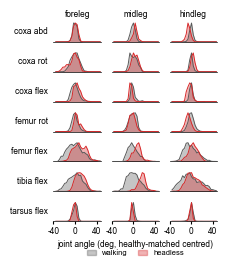


Saved: /home/user/3D_tracking_paper/figure_5/headless_vs_walking/test/joint_angle_distributions_matched_cycles.svg
  50 matched cycles per condition | densities averaged per CYCLE | centred on the healthy matched-cycle mean

joint        tier  Δ median  ROM walk  ROM hless   ratio   vs Output 6 (window frames)
coxa_abduct    T1      +0.7      11.6       12.2    1.05   ratio was 0.88
coxa_abduct    T2      +3.6      12.9       13.5    1.05   ratio was 1.05
coxa_abduct    T3      -4.9       9.4       13.1    1.40   ratio was 1.32
coxa_twist     T1      -2.2      23.6       30.9    1.31   ratio was 1.18
coxa_twist     T2      +4.5      20.2       18.0    0.89   ratio was 0.86
coxa_twist     T3      +3.2       8.6       10.3    1.20   ratio was 1.11
coxa           T1      +3.9      21.9       19.3    0.88   ratio was 0.79
coxa           T2      -3.1      14.1        8.7    0.62   ratio was 0.60
coxa           T3      -2.5       9.9       13.4    1.36   ratio was 1.21
femur_twist    T1    

In [16]:
# ---- FIGURE: joint angle distributions on the SPEED-MATCHED CYCLES only ----
# #
# UNIT IS A CYCLE, so densities are averaged per CYCLE rather than per bout: each of the matched
# cycles contributes one histogram and those are averaged. Output 6 averages per bout, which
# is the right unit for a frame-level figure but the wrong one here.yes
#
# CENTRING: both conditions on the HEALTHY MATCHED-CYCLE mean, so zero means healthy posture
# at matched speed and an off-centre headless curve is a real offset. Same reasoning as

import matplotlib as _mpl
_rc_orig = {k: _mpl.rcParams[k] for k in ('font.family', 'font.size', 'pdf.fonttype',
                                          'ps.fonttype', 'svg.fonttype')}
_mpl.rcParams.update({'font.family': _FONT, 'font.size': 6, 'pdf.fonttype': 42,
                      'ps.fonttype': 42, 'svg.fonttype': 'none'})

# frames belonging to the matched cycles, per condition
_keys_h  = set(zip(_H.bout_id,  _H.cycle))
_keys_hl = set(zip(_HL.bout_id, _HL.cycle))
def _matched_frames(dfp, keys):
    k = list(zip(dfp.bout_id, dfp.step_cycle_id))
    return dfp[[x in keys for x in k]].copy()
MF_H  = _matched_frames(df_h_full,  _keys_h)
MF_HL = _matched_frames(df_hl_full, _keys_hl)
MF_H['cyc_key']  = list(zip(MF_H.bout_id,  MF_H.step_cycle_id))
MF_HL['cyc_key'] = list(zip(MF_HL.bout_id, MF_HL.step_cycle_id))
print(f'matched-cycle frames: healthy {len(MF_H):,} in {MF_H.cyc_key.nunique()} cycles '
      f'({MF_H.fly_id.nunique()} flies); headless {len(MF_HL):,} in '
      f'{MF_HL.cyc_key.nunique()} cycles ({MF_HL.fly_id.nunique()} flies)')
print(f'  cycle speed: healthy median {_H.speed.median():.2f}, '
      f'headless {_HL.speed.median():.2f} mm/s')

_CONDS_M = [('walking', MF_H, COND_COLORS['walking']),
            ('headless', MF_HL, COND_COLORS['headless'])]
_JC = [c for c in [f'{lg}_{j}' for _, lL, lR in _PAIRS_PUB for lg in (lL, lR)
                   for j in _JOINTS_PUB] if c in MF_H.columns]
_JC = list(dict.fromkeys(_JC))
_REF_M = {c: float(MF_H[c].mean()) for c in _JC}       # healthy matched-cycle reference

def _cdeg(df, col):
    return np.degrees(df[col].dropna().values.astype(float) - _REF_M[col])

_lo, _hi = [], []
for _c in _JC:
    for _nm, _df, _ in _CONDS_M:
        v = _cdeg(_df, _c)
        if len(v):
            _lo.append(np.percentile(v, _X_PCT[0])); _hi.append(np.percentile(v, _X_PCT[1]))
_XLO_M, _XHI_M = min(_lo), max(_hi)
_edges_m = np.linspace(_XLO_M, _XHI_M, _N_BINS_PUB + 1)
_cent_m = (_edges_m[:-1] + _edges_m[1:]) / 2

fig_m, axes_m = plt.subplots(len(_JOINTS_PUB), 3,
                             figsize=(FIG_W_MM / 25.4, FIG_H_MM / 25.4), sharex=True)
_stats_m = []
for ci, (tier, legL, legR) in enumerate(_PAIRS_PUB):
    for ri, joint in enumerate(_JOINTS_PUB):
        ax = axes_m[ri, ci]
        _drew = False
        for cond, dfc, colr in _CONDS_M:
            cols = [c for c in (f'{legL}_{joint}', f'{legR}_{joint}') if c in dfc.columns]
            if not cols:
                continue
            dens = []
            for _ck, grp in dfc.groupby('cyc_key', sort=False):     # per CYCLE
                vals = []
                for c in cols:
                    v = grp[c].dropna().values.astype(float)
                    if len(v):
                        vals.extend(np.degrees(v - _REF_M[c]))
                if len(vals) >= 2:
                    dens.append(np.histogram(vals, bins=_edges_m, density=True)[0])
            if not dens:
                continue
            m = np.nanmean(np.vstack(dens), 0)
            pk = float(np.nanmax(m))
            if not np.isfinite(pk) or pk <= 0:
                continue
            ax.fill_between(_cent_m, m / pk, color=colr, alpha=.35, lw=0, zorder=2)
            ax.plot(_cent_m, m / pk, color=colr, lw=.7, zorder=3)
            _drew = True
            allv = np.concatenate([_cdeg(dfc, c) for c in cols])
            p5, p50, p95 = np.percentile(allv, [5, 50, 95])
            _stats_m.append(dict(joint=joint, tier=tier, cond=cond, med=p50,
                                 rom=p95 - p5, n_cyc=len(dens)))
        if not _drew:
            ax.axis('off'); continue
        ax.set_xlim(_XLO_M, _XHI_M); ax.set_ylim(0, 1.10)
        ax.set_yticks([]); ax.tick_params(axis='y', left=False, labelleft=False, length=0)
        for _s in ('left', 'right', 'top'):
            ax.spines[_s].set_visible(False)
        if ri < len(_JOINTS_PUB) - 1:
            ax.spines['bottom'].set_visible(False)
            ax.tick_params(axis='x', bottom=False)
            ax.axhline(0, color='black', lw=.5, clip_on=False, zorder=4)
        if ri == 0:
            ax.set_title(LEG_TITLES.get(tier, tier), fontsize=6, pad=3)
        if ci == 0:
            ax.set_ylabel(JOINT_LABELS.get(joint, joint).lower(), fontsize=6,
                          rotation=0, ha='right', va='center', labelpad=4)
for ci in range(3):
    a = axes_m[len(_JOINTS_PUB) - 1, ci]
    a.set_xticks(list(_XTICKS_DEG)); a.set_xticklabels([f'{x:g}' for x in _XTICKS_DEG])
    a.tick_params(axis='x', labelsize=6, pad=2, length=2)
    a.spines['bottom'].set_linewidth(.5)
# short label: the full wording overran the 52 mm width and got clipped
axes_m[len(_JOINTS_PUB) - 1, 1].set_xlabel('joint angle (deg, healthy-matched centred)',
                                           fontsize=6, labelpad=3)
from matplotlib.patches import Patch
fig_m.legend(handles=[Patch(facecolor=c, alpha=.35, edgecolor=c, label=n)
                      for n, _, c in _CONDS_M],
             loc='lower center', bbox_to_anchor=(.59, -.035), fontsize=5.5,
             frameon=False, ncol=2, handlelength=1.2, columnspacing=1.4)
plt.subplots_adjust(left=.19, right=.99, top=.955, bottom=.135, hspace=.45, wspace=.22)
_out_m = OUTPUT_DIR / 'joint_angle_distributions_matched_cycles.svg'
fig_m.savefig(_out_m, bbox_inches='tight')
fig_m.savefig(str(_out_m).replace('.svg', '.png'), bbox_inches='tight', dpi=300)
plt.show()

SM = pd.DataFrame(_stats_m)
print(f'\nSaved: {_out_m}')
print(f'  {len(_H)} matched cycles per condition | densities averaged per CYCLE | '
      f'centred on the healthy matched-cycle mean')
print(f'\n{"joint":<12}{"tier":>5}{"Δ median":>10}{"ROM walk":>10}{"ROM hless":>11}'
      f'{"ratio":>8}   vs Output 6 (window frames)')
_prev = S.set_index(['joint', 'tier', 'cond'])
for j in _JOINTS_PUB:
    for t in ('T1', 'T2', 'T3'):
        w = SM[(SM.joint == j) & (SM.tier == t) & (SM.cond == 'walking')]
        h = SM[(SM.joint == j) & (SM.tier == t) & (SM.cond == 'headless')]
        if w.empty or h.empty:
            continue
        rr = h.rom.iloc[0] / w.rom.iloc[0]
        try:
            pr = (_prev.loc[(j, t, 'headless'), 'rom']
                  / _prev.loc[(j, t, 'walking'), 'rom'])
            ptxt = f'{pr:.2f}'
        except KeyError:
            ptxt = '-'
        print(f'{j:<12}{t:>5}{h.med.iloc[0]-w.med.iloc[0]:>+10.1f}'
              f'{w.rom.iloc[0]:>10.1f}{h.rom.iloc[0]:>11.1f}{rr:>8.2f}'
              f'   ratio was {ptxt}')
print('\n  ROM ratios here are at FLAT speed; the Output 6 column is at merely bounded speed')
print('  where healthy walked ~2x faster, so it exaggerated the healthy range. Differences')
print('  between the two columns are the part of Output 6 that was residual speed.')
_mpl.rcParams.update(_rc_orig)


####  per-cycle PC1–PC2 loops

In [13]:
# ---- MACHINERY ONLY: the per-cycle PC1-PC2 loops ----
# Builds _LOOPS (one closed loop per matched cycle) and the paired tables _H / _HL.
# The 50-panel overlay figure it used to draw is not a deliverable here.
#
# Output 9 reports loop area x0.60 and perimeter x0.64 at matched speed. Those numbers come
# from the shoelace area and path length of ONE closed PC1-PC2 loop per step cycle, so this
# cell draws those loops. speed-matched pairs, nothing pooled.
#
# Panels a/b show the loops where they actually sit in PC space. Panels c/d recentre each
# loop on its own centroid -- area and perimeter are translation-invariant, so that is the
# honest way to compare SIZE without position differences confusing it.
_H  = CYC_H.iloc[PAIRS.i_h.values].reset_index(drop=True)
_HL = CYC_HL.iloc[PAIRS.i_hl.values].reset_index(drop=True)
_ch, _cl = COND_COLORS['walking'], COND_COLORS['headless']

def _loop_xy(dfp, bout_id, cycle):
    g = dfp[(dfp.bout_id == bout_id) & (dfp.step_cycle_id == cycle)]
    return g.PC1.values, g.PC2.values

_LOOPS = {'walking': [], 'headless': []}
for k in range(len(PAIRS)):
    _LOOPS['walking'].append(_loop_xy(df_h_full,  _H.bout_id[k],  _H.cycle[k]))
    _LOOPS['headless'].append(_loop_xy(df_hl_full, _HL.bout_id[k], _HL.cycle[k]))
print(f'{len(PAIRS)} matched pairs; loop lengths: '
      f'healthy median {np.median([len(x) for x, _ in _LOOPS["walking"]]):.0f} frames, '
      f'headless {np.median([len(x) for x, _ in _LOOPS["headless"]]):.0f}')

# recentred spans, to confirm the figure shows what the numbers say
for nm in ('walking', 'headless'):
    sp = [max(np.ptp(x), np.ptp(y)) for x, y in _LOOPS[nm] if len(x) > 2]
    print(f'  {nm:<9} recentred loop span: median {np.median(sp):.2f} PC units')


50 matched pairs; loop lengths: healthy median 161 frames, headless 157
  walking   recentred loop span: median 6.41 PC units
  headless  recentred loop span: median 4.28 PC units


####  PC1–PC2 densities

In [14]:
# ---- MACHINERY ONLY: the PC1-PC2 densities the final panel draws ----
# Output 11b's own figure is not a deliverable here, so only the estimation and the
# numbers it prints are kept: PDF_PTS / PDF_Z / PDF_K / _GX / _GY / _cell /
# _hdr_levels / _resample_loop are what the panel consumes.
#
# Output 11 draws 79 loops per condition on top of each other; past about twenty the ink stops
# adding information and the eye reads whichever colour was drawn last. The density says the
# same thing without the pile-up: where in the PC1-PC2 plane each condition spends its cycles.
#
# THE UNIT IS STILL A CYCLE. Frames are not equally spaced along a loop -- a slow cycle carries
# more of them -- so pooling raw frames would weight slow cycles more heavily and quietly turn
# a speed difference into a density difference. Each loop is therefore resampled to
# PDF_N_PER_LOOP points evenly spaced ALONG ITS OWN PATH, so every cycle contributes the same
# mass and the density describes shape, not sampling.
#
# THE CONTOURS ARE HIGHEST-DENSITY REGIONS, not arbitrary levels: the line labelled 50% is the
# smallest region containing half of the probability mass, and the shaded one 90%. That makes
# the areas readable as numbers -- an HDR area IS a size, in PC units squared, and its ratio
# between conditions is comparable with the loop-area ratio Output 9 reports.
#
# WHAT TO READ. Displacement of the 50% cores = the conditions occupy different parts of the
# space. A smaller headless core at the same place = the same behaviour, smaller. The overlap
# fraction printed below is the honest summary of "is headless inside the healthy space",
# measured as the share of headless mass falling inside the healthy 90% region.
PDF_LABELS = {'walking': 'intact, walking', 'headless': 'headless'}
PDF_N_PER_LOOP = 120
PDF_GRID = 220
PDF_LEVELS = (.5, .9)          # highest-density regions to draw
PDF_BW = .28                   # KDE bandwidth, in units of the pooled standard deviation

def _resample_loop(x, y, n=PDF_N_PER_LOOP):
    """Even spacing along the loop's own path, so every cycle carries the same mass."""
    p = np.c_[np.r_[x, x[:1]], np.r_[y, y[:1]]]
    d = np.r_[0, np.cumsum(np.linalg.norm(np.diff(p, axis=0), axis=1))]
    if d[-1] <= 0:
        return None
    t = np.linspace(0, d[-1], n, endpoint=False)
    return np.c_[np.interp(t, d, p[:, 0]), np.interp(t, d, p[:, 1])]

PDF_PTS = {}
for _nm in ('walking', 'headless'):
    _pts = [_resample_loop(x, y) for x, y in _LOOPS[_nm] if len(x) > 3]
    PDF_PTS[_nm] = np.concatenate([p for p in _pts if p is not None])
    print(f'{_nm:<9} {len(_pts)} cycles -> {len(PDF_PTS[_nm]):,} equally weighted points')

from scipy.stats import gaussian_kde
_ALL = np.concatenate(list(PDF_PTS.values()))
# A SQUARE WINDOW, and a square panel to draw it in: PC1 and PC2 are the same kind of unit,
# so a millimetre of PC1 must be a millimetre of PC2 or the shapes lie. Matplotlib's
# set_aspect('equal') cannot do this here -- it is refused on axes shared with the marginals,
# and 'box' shrinks the panel out from under them -- so the grid is built square instead.
_mid = (_ALL.max(0) + _ALL.min(0)) / 2
_half = .5 * float(np.max(np.ptp(_ALL, axis=0))) * 1.10
_gx = np.linspace(_mid[0] - _half, _mid[0] + _half, PDF_GRID)
_gy = np.linspace(_mid[1] - _half, _mid[1] + _half, PDF_GRID)
_GX, _GY = np.meshgrid(_gx, _gy)
_cell = (_gx[1] - _gx[0]) * (_gy[1] - _gy[0])

def _density(pts):
    k = gaussian_kde(pts.T, bw_method=PDF_BW)
    z = k(np.vstack([_GX.ravel(), _GY.ravel()])).reshape(_GX.shape)
    return z / (z.sum() * _cell), k

def _hdr_levels(z, fracs=PDF_LEVELS):
    """Density values enclosing the given share of the mass, largest region last."""
    flat = np.sort(z.ravel())[::-1]
    csum = np.cumsum(flat) * _cell
    return [flat[np.searchsorted(csum, f)] for f in fracs]

PDF_Z, PDF_K = {}, {}
for _nm in ('walking', 'headless'):
    PDF_Z[_nm], PDF_K[_nm] = _density(PDF_PTS[_nm])

# ---- the numbers the picture is making ----
print(f'\n{"":>10}{"50% HDR area":>15}{"90% HDR area":>15}   (PC units squared)')
_area = {}
for _nm in ('walking', 'headless'):
    lv = _hdr_levels(PDF_Z[_nm])
    _area[_nm] = [float((PDF_Z[_nm] >= l).sum() * _cell) for l in lv]
    print(f'{_nm:>10}{_area[_nm][0]:>15.2f}{_area[_nm][1]:>15.2f}')
print(f'{"ratio":>10}{_area["headless"][0]/_area["walking"][0]:>15.2f}'
      f'{_area["headless"][1]/_area["walking"][1]:>15.2f}'
      f'   headless / healthy — compare with the loop-area ratio in Output 9')
_lv_h = _hdr_levels(PDF_Z['walking'])[-1]
_inside = PDF_K['walking'](PDF_PTS['headless'].T) >= _lv_h
print(f'\n{_inside.mean()*100:.0f}% of the headless mass falls inside the healthy 90% region '
      f'({(PDF_K["headless"](PDF_PTS["walking"].T) >= _hdr_levels(PDF_Z["headless"])[-1]).mean()*100:.0f}%'
      f' the other way round)')
_cen = {nm: PDF_PTS[nm].mean(0) for nm in PDF_PTS}
print(f'centroid shift: PC1 {_cen["headless"][0]-_cen["walking"][0]:+.2f}, '
      f'PC2 {_cen["headless"][1]-_cen["walking"][1]:+.2f} PC units')


walking   50 cycles -> 6,000 equally weighted points
headless  50 cycles -> 6,000 equally weighted points

             50% HDR area   90% HDR area   (PC units squared)
   walking          15.79          49.49
  headless           9.56          23.91
     ratio           0.61           0.48   headless / healthy — compare with the loop-area ratio in Output 9

100% of the headless mass falls inside the healthy 90% region (68% the other way round)
centroid shift: PC1 -0.15, PC2 +0.07 PC units


### Figure 5d


typeface: Arial


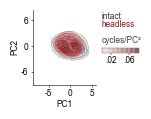


panel 45 × 25 mm exactly (no bbox trimming), Arial 6 pt
style 'steps' · colour = ABSOLUTE DENSITY, 8 bands of 0.01 cycles/PC² from 0.005 up to 0.08
  peak density  intact 0.0449  headless 0.0700  -> denser by 1.56x
  the bar runs 0 to 0.08 cycles/PC²; the flatter condition tops out at 0.0449, i.e. 56% along it. That IS the comparison.
fit 'box' · drawing box 16.0 × 19.0 mm · window PC1 [-8.73, 5.91] PC2 [-9.00, 8.42] · 0.84:1, equal aspect, nothing cropped
HDR areas (PC²)  intact 15.79 / 49.49   headless 9.56 / 23.91   core ratio 0.61×
wrote /home/user/3D_tracking_paper/figure_5/headless_vs_walking/test/pc_density_panel_42x25.svg | .pdf | .png


In [19]:
# ---- FIGURE (panel): 
#
# THE BAR CARRIES ABSOLUTE DENSITY, in cycles per PC squared. A 2-D density is not bounded by
# 1 -- only its INTEGRAL is -- so its values depend on how spread out the distribution is: one
# unit of probability over ~37 PC squared gives a peak near 0.04, and a tenfold tighter cloud
# would give a hundredfold larger one. Both conditions integrate to 1 over the same plane, so
# their values are directly comparable and the ramp is necessarily shared: a condition that is
# more concentrated comes out darker, which is the result rather than an artefact. The cost is
# that the flatter one spans only the lower part of the bar.
#
# THE STEP IS A ROUND NUMBER IN THOSE UNITS. PANEL_DENS_STEP = None picks one automatically --
# 1, 2, 2.5 or 5 times a power of ten, whichever gives about PANEL_DENS_NBANDS bands up to the
# peak -- so the band edges and the bar ticks land on values a reader can say out loud, rather
# than on tenths of whatever the peak happened to be.
##
PANEL_W_MM, PANEL_H_MM = 45.0, 25.0
PANEL_FS = 6.0
PANEL_PAD = .06                      # window padding, as a fraction of the data range
PANEL_KEY = True                     # the two-word inline key; False leaves it to the caption
PANEL_FIT = 'box'                    # 'box' draws the data largest; 'window' fills the rect
PANEL_STYLE = 'steps'                # 'steps' = mass deciles | 'hdr' = the old 50/90 rings
PANEL_DENS_STEP = None               # band width in cycles/PC^2; None picks a round one
PANEL_DENS_NBANDS = 9                # bands up to the peak, when the step is chosen for you
PANEL_FLOOR_STEPS = 0.5              # outer edge in steps of density; 0.5 -> 0.005, a half
                                     # step, so the lowest band is 0.005-0.01
                                     # the plate is now purely density-based
PANEL_A_CORE = .78                   # opacity of the densest band
PANEL_A_TAIL = .12                   # opacity of the outermost band
PANEL_DARKEN = .40                   # the densest band also mixes this far toward black
PANEL_LINE_LW = .22                  # the thin limit on every band edge
PANEL_LINE_A  = .50                  # 18 edges are drawn; keep each one quiet
PANEL_BAR_LABEL = 'cycles/PC²'        # absolute density; 17
                                     # across the field, so it is kept to the bar's width
PANEL_BAR = True                     # the reference bar for the gradient
PANEL_SIDE = True                    # key and bar in the right margin, off the distribution
PANEL_BAR_RECT = (.03, .115, .72, .085)   # used only when PANEL_SIDE is False
                                     # only 16 mm wide on real data, so .46 gave a 7.4 mm
                                     # bar and the two 2.7 mm labels collided
PANEL_BAR_NTICKS = 2                 # '.02' is 2.7 mm at 6 pt; three of them collide in a
                                     # 12 mm bar, so two evenly spaced is the safe default
PANEL_ALLOW_FALLBACK = False
PANEL_OUT = 'pc_density_panel_42x25'
# margins in mm, measured for 6 pt Arial: room for a tick label plus an axis title
PANEL_M = dict(left=6.4, right=0.8, bottom=5.2, top=0.8)
import numpy as np
import glob as _glob
import matplotlib as _mpl
import matplotlib.font_manager as _fmgr

for _f in _glob.glob('/usr/share/fonts/**/[Aa]rial*.ttf', recursive=True) + \
          _glob.glob('/usr/share/fonts/**/arial*.ttf', recursive=True):
    try:
        _fmgr.fontManager.addfont(_f)
    except Exception:
        pass
_HAVE_ARIAL = 'Arial' in {f.name for f in _fmgr.fontManager.ttflist}
if not _HAVE_ARIAL and not PANEL_ALLOW_FALLBACK:
    raise RuntimeError(
        'Arial not resolvable by matplotlib, and it would silently fall back to DejaVu Sans. '
        'Install ttf-mscorefonts-installer, or set PANEL_ALLOW_FALLBACK = True to accept a '
        'metric-compatible stand-in (Liberation Sans / Arimo).')
_PANEL_FAMILY = ['Arial'] if _HAVE_ARIAL else ['Liberation Sans', 'Arimo', 'DejaVu Sans']
print(f'typeface: {_PANEL_FAMILY[0]}' + ('' if _HAVE_ARIAL else '   [FALLBACK — not Arial]'))

MM = 1 / 25.4

def _panel_window(pts, pad=PANEL_PAD):
    """The data's own window, padded. Its shape is what the box is then fitted to."""
    x0, y0 = pts.min(0); x1, y1 = pts.max(0)
    dx, dy = x1 - x0, y1 - y0
    return x0 - pad * dx, x1 + pad * dx, y0 - pad * dy, y1 + pad * dy


def _darker(c, f=.38):
    r, g, b = mpl.colors.to_rgb(c)
    return (r * (1 - f), g * (1 - f), b * (1 - f))

_aw = PANEL_W_MM - PANEL_M['left'] - PANEL_M['right']     # available drawing area
_ah = PANEL_H_MM - PANEL_M['bottom'] - PANEL_M['top']
_x0, _x1, _y0, _y1 = _panel_window(np.concatenate(list(PDF_PTS.values())))
_da = (_x1 - _x0) / (_y1 - _y0)
if PANEL_FIT == 'box':
    _bw = min(_aw, _ah * _da); _bh = _bw / _da            # box takes the data's shape
    _lft = PANEL_M['left'] + (_aw - _bw) / 2
    _bot = PANEL_M['bottom'] + (_ah - _bh) / 2
else:
    _bw, _bh = _aw, _ah                                   # window takes the box's shape
    _lft, _bot = PANEL_M['left'], PANEL_M['bottom']
    if _da < _bw / _bh:
        _need = (_y1 - _y0) * (_bw / _bh); _c = (_x0 + _x1) / 2
        _x0, _x1 = _c - _need / 2, _c + _need / 2
    else:
        _need = (_x1 - _x0) / (_bw / _bh); _c = (_y0 + _y1) / 2
        _y0, _y1 = _c - _need / 2, _c + _need / 2

def _nice_step(peak, n=PANEL_DENS_NBANDS):
    """A round band width: 1, 2, 2.5 or 5 times a power of ten, giving about n bands."""
    raw = peak / max(n, 1)
    e = np.floor(np.log10(raw))
    base = raw / 10 ** e
    nice = next(v for v in (1, 2, 2.5, 5, 10) if base <= v)
    return float(nice * 10 ** e)

def _fmt_dens(v):
    """Compact tick label: no leading zero, no trailing noise. 6 pt has no room for '0.020'."""
    s = f'{v:.10f}'.rstrip('0').rstrip('.')
    return s[1:] if s.startswith('0.') else s

def _dens_alpha(frac):
    """Opacity for a band whose density is `frac` of the reference peak."""
    return PANEL_A_TAIL + (PANEL_A_CORE - PANEL_A_TAIL) * np.clip(frac, 0, 1)

def _dens_face(colour, frac):
    """Fill colour for that band: the hue, mixed toward black as density rises."""
    return tuple(np.array(mpl.colors.to_rgb(colour))
                 * (1 - PANEL_DARKEN * float(np.clip(frac, 0, 1))))

def _mass_levels(zn, masses):
    """Density level enclosing each given mass. zn integrates to 1, so the descending
    cumulative sum of its values times the cell area is the mass at or above that density."""
    f = np.sort(zn.ravel())[::-1]
    c = np.cumsum(f) * _cell
    return np.array([float(f[np.searchsorted(c, m)]) for m in masses])

_rc = {
    'font.family': 'sans-serif', 'font.sans-serif': _PANEL_FAMILY, 'font.size': PANEL_FS,
    'axes.labelsize': PANEL_FS, 'xtick.labelsize': PANEL_FS, 'ytick.labelsize': PANEL_FS,
    'axes.linewidth': .4, 'xtick.major.width': .4, 'ytick.major.width': .4,
    'xtick.major.size': 1.6, 'ytick.major.size': 1.6,
    'xtick.major.pad': 1.6, 'ytick.major.pad': 1.6, 'axes.labelpad': 1.4,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.unicode_minus': False,
}
with plt.rc_context(_rc):
    fig_p = plt.figure(figsize=(PANEL_W_MM * MM, PANEL_H_MM * MM))
    ax = fig_p.add_axes([_lft / PANEL_W_MM, _bot / PANEL_H_MM,
                         _bw / PANEL_W_MM, _bh / PANEL_H_MM])
    _peak = float(max(PDF_Z[n].max() for n in ('walking', 'headless')))
    _step = _nice_step(_peak) if PANEL_DENS_STEP is None else float(PANEL_DENS_STEP)
    _nband = int(np.ceil(_peak / _step))
    _top = _nband * _step                       # the bar's right-hand end, a round number
    for _nm in ('walking', 'headless'):
        c = COND_COLORS[_nm]
        if PANEL_STYLE == 'steps':
            # shape bounded by mass, colour inside it stepped by absolute density
            _floor = PANEL_FLOOR_STEPS * _step or 1e-12
            _e = np.arange(1, _nband) * _step
            _e = np.r_[_floor, _e[_e > _floor]]
            for _k in range(len(_e)):
                _lo = _e[_k]
                _hi = _e[_k + 1] if _k + 1 < len(_e) else np.inf
                _fr = ((_lo + (_hi if np.isfinite(_hi) else _top)) / 2) / _top
                ax.contourf(_GX, _GY, PDF_Z[_nm], levels=[_lo, _hi],
                            colors=[_dens_face(c, _fr)], alpha=float(_dens_alpha(_fr)), zorder=2)
            ax.contour(_GX, _GY, PDF_Z[_nm], levels=_e, colors=[_darker(c, .25)],
                       linewidths=PANEL_LINE_LW, alpha=PANEL_LINE_A, zorder=3)
        else:
            lv = sorted(_hdr_levels(PDF_Z[_nm]))
            for lo, hi, al in ((lv[0], lv[1], .12), (lv[1], np.inf, .30)):
                ax.contourf(_GX, _GY, PDF_Z[_nm], levels=[lo, hi], colors=[c], alpha=al,
                            zorder=2)
            ax.contour(_GX, _GY, PDF_Z[_nm], levels=lv, colors=[c, c],
                       linewidths=[.5, .9], zorder=3)
        # the example cycle, cased so it survives crossing its own fill

    ax.set_xlim(_x0, _x1); ax.set_ylim(_y0, _y1)      # window already carries the box shape
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax.spines[['top', 'right']].set_visible(False)
    _sx = (_lft + _bw + 1.6) / PANEL_W_MM      # right margin, in figure fractions
    if PANEL_KEY:
        for _i, (_nm, _lab) in enumerate((('walking', 'intact'), ('headless', 'headless'))):
            if PANEL_SIDE:
                fig_p.text(_sx, (_bot + _bh - 0.4 - _i * 2.2) / PANEL_H_MM, _lab,
                           color=_darker(COND_COLORS[_nm]), fontsize=PANEL_FS,
                           ha='left', va='top')
            else:
                ax.text(.025, .965 - _i * .125, _lab, transform=ax.transAxes,
                        color=_darker(COND_COLORS[_nm]), fontsize=PANEL_FS, ha='left', va='top')
    if PANEL_STYLE == 'steps' and PANEL_BAR:
        # Two rows, in the same order as the labels above, so hue -> condition is spatial:
        # there is no room in 42 mm to name the conditions beside the bar as well. One block
        # per band, in the same order and the same opacities as the plate.
        # No backing panel: a filled rectangle here cuts a visible hard edge through the
        # field, which reads as data. The outermost bands are faint enough to sit under.
        if PANEL_SIDE:
            _bwmm = PANEL_W_MM - PANEL_M['right'] - (_lft + _bw + 1.6)
            _cb = fig_p.add_axes([_sx, (_bot + _bh - 11.0) / PANEL_H_MM,
                                  _bwmm / PANEL_W_MM, 1.4 / PANEL_H_MM], zorder=4)
        else:
            _cb = ax.inset_axes(PANEL_BAR_RECT, zorder=4)
        _mids = (np.arange(_nband) + .5) * _step / _top      # low density at the left
        _strip = np.zeros((2, _nband, 4))
        for _r, _n2 in enumerate(('walking', 'headless')):
            _strip[_r, :, :3] = [_dens_face(COND_COLORS[_n2], _m) for _m in _mids]
            _strip[_r, :, 3] = _dens_alpha(_mids)
        _cb.imshow(_strip, origin='upper', aspect='auto', interpolation='nearest',
                   extent=[0, _top, 0, 1])
        for _v in np.arange(1, _nband) * _step:
            _cb.axvline(_v, color='white', lw=.3, zorder=4)   # the same limits as the plate
        # ticks on band edges, so every label is a round multiple of the step
        # spread across the bar, not bunched: (i+.5)/n puts two ticks at 1/4 and 3/4,
        # where (i+1)/(n+1) put them at 1/3 and 2/3 and the labels touched
        _tk = sorted({int(round(_nband * (i + .5) / PANEL_BAR_NTICKS)) * _step
                      for i in range(PANEL_BAR_NTICKS)} - {0.0})
        _cb.set_yticks([]); _cb.set_xticks(_tk)
        _cb.set_xticklabels([_fmt_dens(v) for v in _tk])
        _cb.tick_params(length=1.1, width=.35, pad=1.0, labelsize=PANEL_FS)
        for _sp in _cb.spines.values():
            _sp.set_linewidth(.35); _sp.set_color('0.45')
        _cb.patch.set_alpha(0)
        # the caption goes ABOVE the bar, not beside it: beside it there is no width left
        _cb.text(0, 1.45, PANEL_BAR_LABEL, transform=_cb.transAxes, fontsize=PANEL_FS,
                 va='bottom', ha='left', color='0.25')

    for _ext in ('svg', 'pdf', 'png'):
        fig_p.savefig(OUTPUT_DIR / f'{PANEL_OUT}.{_ext}', dpi=1200,
                      facecolor='white', edgecolor='none')   # no bbox_inches: size is exact
    plt.show()

_a = {n: [float((PDF_Z[n] >= l).sum() * _cell) for l in _hdr_levels(PDF_Z[n])]
      for n in ('walking', 'headless')}
print(f'\npanel {PANEL_W_MM:g} × {PANEL_H_MM:g} mm exactly (no bbox trimming), '
      f'{_PANEL_FAMILY[0]} {PANEL_FS:g} pt')
print(f'style {PANEL_STYLE!r}' + (f' · colour = ABSOLUTE DENSITY, {_nband} bands of '
      f'{_step:g} cycles/PC² from {PANEL_FLOOR_STEPS*_step:g} up to {_top:g}' if PANEL_STYLE == 'steps' else ''))
if PANEL_STYLE == 'steps':
    _pk = {n: float(PDF_Z[n].max()) for n in ('walking', 'headless')}
    print(f'  peak density  intact {_pk["walking"]:.4f}  headless {_pk["headless"]:.4f}  '
          f'-> denser by {max(_pk.values())/min(_pk.values()):.2f}x')
    print(f'  the bar runs 0 to {_top:g} cycles/PC²; the flatter condition tops out at '
          f'{min(_pk.values()):.4f}, i.e. {min(_pk.values())/_top*100:.0f}% along it. '
          f'That IS the comparison.')
print(f'fit \'{PANEL_FIT}\' · drawing box {_bw:.1f} × {_bh:.1f} mm · window '
      f'PC1 [{_x0:.2f}, {_x1:.2f}] PC2 [{_y0:.2f}, {_y1:.2f}] · '
      f'{(_x1-_x0)/(_y1-_y0):.2f}:1, equal aspect, nothing cropped')
print(f'HDR areas (PC²)  intact {_a["walking"][0]:.2f} / {_a["walking"][1]:.2f}   '
      f'headless {_a["headless"][0]:.2f} / {_a["headless"][1]:.2f}   '
      f'core ratio {_a["headless"][0]/_a["walking"][0]:.2f}×')
print(f'wrote {OUTPUT_DIR}/{PANEL_OUT}.svg | .pdf | .png')
